# Phase 2 — MobileNetV2 Fine-tuning & Grad-CAM (Beginner Friendly)

**Purpose:** Fine-tune MobileNetV2 on your Alzheimer MRI dataset, evaluate vs baseline, and generate Grad-CAM visualizations for all 4 classes.

**Where this notebook should be placed:** 
`C:\Users\Ayush\Alzheimer_Project\Phase2_MobileNetV2_GradCAM.ipynb`

**Important:** Open this notebook in **Anaconda (alzthesis environment)** via Jupyter Notebook. Follow each step and run cells in order (Shift+Enter).

If you completed Phase 1 successfully, your dataset folder should be at:
`C:\Users\Ayush\Alzheimer_Project\Alzheimer_Dataset`

Baseline model (from Phase 1) path (used only for comparison):
`C:\Users\Ayush\Alzheimer_Project\models\baseline_cnn_best.h5`

All outputs (models, logs, gradcam images) will be saved to:
`C:\Users\Ayush\Alzheimer_Project\outputs\`

---


## Step 0 — Before you start (Anaconda Checklist)
1. Open **Anaconda Navigator** → **Environments** → select **alzthesis** → click **Open Terminal**.
2. In terminal, ensure required packages are installed (you may have them from Phase 1):

 ```bash
 conda activate alzthesis
 pip install tensorflow matplotlib numpy pandas scikit-learn opencv-python pillow
 ```
3. Launch **Jupyter Notebook** from the `alzthesis` environment and open this notebook.


## Step 1 — Imports (Run this cell)
This cell imports required libraries and sets reproducibility seeds. If you see warnings about `requests` missing chardet, ignore or install `chardet` via pip.

In [1]:
import os, random, math, shutil, json, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import cv2

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import load_model

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Reproducibility
seed = 42
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)

print('TensorFlow version:', tf.__version__)
print('GPU available:', tf.config.list_physical_devices('GPU'))


TensorFlow version: 2.20.0
GPU available: []


## Step 2 — Define paths (Edit if your paths differ)
Make sure these paths match your local folders exactly. If your `Alzheimer_Dataset` or models folder is in a different location, update the paths below.

In [2]:
PROJECT_DIR = r'C:\Users\Ayush\Alzheimer_Project'
DATA_DIR = os.path.join(PROJECT_DIR, 'Alzheimer_Dataset')   # contains class subfolders
MODELS_DIR = os.path.join(PROJECT_DIR, 'models')
OUTPUTS_DIR = os.path.join(PROJECT_DIR, 'outputs')
GRADCAM_DIR = os.path.join(OUTPUTS_DIR, 'gradcam_visuals')

os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(OUTPUTS_DIR, exist_ok=True)
os.makedirs(GRADCAM_DIR, exist_ok=True)

print('Project dir:', PROJECT_DIR)
print('Data dir:', DATA_DIR)
print('Models dir:', MODELS_DIR)
print('Outputs dir:', OUTPUTS_DIR)
print('Grad-CAM output dir:', GRADCAM_DIR)


Project dir: C:\Users\Ayush\Alzheimer_Project
Data dir: C:\Users\Ayush\Alzheimer_Project\Alzheimer_Dataset
Models dir: C:\Users\Ayush\Alzheimer_Project\models
Outputs dir: C:\Users\Ayush\Alzheimer_Project\outputs
Grad-CAM output dir: C:\Users\Ayush\Alzheimer_Project\outputs\gradcam_visuals


## Step 3 — Data Generators (Preprocessing & Augmentation)
We will reuse the same preprocessing as Phase 1: images resized to 224×224 and rescaled to [0,1].
Run this cell to create training, validation, and test generators.

In [3]:
IMG_SIZE = (224,224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    validation_split=0.2
)
val_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=seed
)

val_gen = train_datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=seed
)

test_datagen = ImageDataGenerator(rescale=1./255)
test_gen = test_datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False,
    seed=seed
)

class_indices = train_gen.class_indices
print('Class mapping:', class_indices)
num_classes = len(class_indices)


Found 69151 images belonging to 4 classes.
Found 17286 images belonging to 4 classes.
Found 86437 images belonging to 4 classes.
Class mapping: {'Mild Dementia': 0, 'Moderate Dementia': 1, 'Non Demented': 2, 'Very mild Dementia': 3}


## Step 4 — Load MobileNetV2 (Pretrained) and Build Model (Transfer Learning)
We'll load MobileNetV2 with ImageNet weights, exclude the top, add global pooling and a small classification head.
Run this cell to create the model.

In [4]:
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
base_model.trainable = False
print('Base model loaded. Trainable layers:', sum([1 for l in base_model.layers if l.trainable]))

inputs = layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)
mobilenet_model = models.Model(inputs, outputs)

mobilenet_model.compile(optimizer=optimizers.Adam(learning_rate=1e-4),
                        loss='categorical_crossentropy',
                        metrics=['accuracy'])

mobilenet_model.summary()


Base model loaded. Trainable layers: 0


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │         5,124 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,263,108 (8.63 MB)

 Trainable params: 5,124 (20.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## Step 5 — Train the MobileNetV2 (Top Head, base frozen)
Train for a few epochs with the base frozen to adapt the head. You can increase epochs later.

In [5]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

checkpoint_path = os.path.join(MODELS_DIR, 'mobilenetv2_head.h5')
callbacks = [
    ModelCheckpoint(checkpoint_path, save_best_only=True, monitor='val_loss', verbose=1),
    EarlyStopping(patience=6, monitor='val_loss', restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
]

history1 = mobilenet_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=8,
    callbacks=callbacks
)

pd.DataFrame(history1.history).to_csv(os.path.join(OUTPUTS_DIR, 'mobilenet_head_history.csv'), index=False)
print('Initial head training complete. Best model saved to:', checkpoint_path)


Epoch 1/8
2161/2161 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7135 - loss: 0.8055
Epoch 1: val_loss improved from None to 0.59420, saving model to C:\Users\Ayush\Alzheimer_Project\models\mobilenetv2_head.h5



Epoch 1: finished saving model to C:\Users\Ayush\Alzheimer_Project\models\mobilenetv2_head.h5
2161/2161 ━━━━━━━━━━━━━━━━━━━━ 8128s 4s/step - accuracy: 0.7549 - loss: 0.6934 - val_accuracy: 0.7767 - val_loss: 0.5942 - learning_rate: 1.0000e-04
Epoch 2/8
2161/2161 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7745 - loss: 0.5970
Epoch 2: val_loss improved from 0.59420 to 0.58399, saving model to C:\Users\Ayush\Alzheimer_Project\models\mobilenetv2_head.h5



Epoch 2: finished saving model to C:\Users\Ayush\Alzheimer_Project\models\mobilenetv2_head.h5
2161/2161 ━━━━━━━━━━━━━━━━━━━━ 11423s 5s/step - accuracy: 0.7780 - loss: 0.5823 - val_accuracy: 0.7769 - val_loss: 0.5840 - learning_rate: 1.0000e-04
Epoch 3/8
2161/2161 ━━━━━━━━━━━━━━━━━━━━ 0s 48s/step - accuracy: 0.7833 - loss: 0.5493 
Epoch 3: val_loss improved from 0.58399 to 0.57602, saving model to C:\Users\Ayush\Alzheimer_Project\models\mobilenetv2_head.h5



Epoch 3: finished saving model to C:\Users\Ayush\Alzheimer_Project\models\mobilenetv2_head.h5
2161/2161 ━━━━━━━━━━━━━━━━━━━━ 105549s 49s/step - accuracy: 0.7840 - loss: 0.5454 - val_accuracy: 0.7726 - val_loss: 0.5760 - learning_rate: 1.0000e-04
Epoch 4/8
2161/2161 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7890 - loss: 0.5314
Epoch 4: val_loss improved from 0.57602 to 0.57214, saving model to C:\Users\Ayush\Alzheimer_Project\models\mobilenetv2_head.h5



Epoch 4: finished saving model to C:\Users\Ayush\Alzheimer_Project\models\mobilenetv2_head.h5
2161/2161 ━━━━━━━━━━━━━━━━━━━━ 42775s 20s/step - accuracy: 0.7895 - loss: 0.5293 - val_accuracy: 0.7733 - val_loss: 0.5721 - learning_rate: 1.0000e-04
Epoch 5/8
2161/2161 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.7958 - loss: 0.5100
Epoch 5: val_loss improved from 0.57214 to 0.56793, saving model to C:\Users\Ayush\Alzheimer_Project\models\mobilenetv2_head.h5



Epoch 5: finished saving model to C:\Users\Ayush\Alzheimer_Project\models\mobilenetv2_head.h5
2161/2161 ━━━━━━━━━━━━━━━━━━━━ 8701s 4s/step - accuracy: 0.7932 - loss: 0.5150 - val_accuracy: 0.7763 - val_loss: 0.5679 - learning_rate: 1.0000e-04
Epoch 6/8
2161/2161 ━━━━━━━━━━━━━━━━━━━━ 0s 49s/step - accuracy: 0.7950 - loss: 0.5069 
Epoch 6: val_loss did not improve from 0.56793
2161/2161 ━━━━━━━━━━━━━━━━━━━━ 106988s 50s/step - accuracy: 0.7944 - loss: 0.5074 - val_accuracy: 0.7737 - val_loss: 0.5696 - learning_rate: 1.0000e-04
Epoch 7/8
2161/2161 ━━━━━━━━━━━━━━━━━━━━ 0s 28s/step - accuracy: 0.7962 - loss: 0.5025 
Epoch 7: val_loss did not improve from 0.56793
2161/2161 ━━━━━━━━━━━━━━━━━━━━ 61746s 29s/step - accuracy: 0.7958 - loss: 0.5054 - val_accuracy: 0.7735 - val_loss: 0.5682 - learning_rate: 1.0000e-04
Epoch 8/8
2161/2161 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7955 - loss: 0.5062
Epoch 8: val_loss did not improve from 0.56793

Epoch 8: ReduceLROnPlateau reducing learning rate

## Step 6 — Unfreeze some layers & Fine-tune
We'll unfreeze the top layers of MobileNetV2 (e.g., last 20 layers) and continue training with a lower learning rate.

In [6]:
base_model.trainable = True

N = 20
for layer in base_model.layers[:-N]:
    layer.trainable = False

print('Trainable layers after unfreezing:', sum([1 for l in base_model.layers if l.trainable]))

mobilenet_model.compile(optimizer=optimizers.Adam(learning_rate=1e-5),
                        loss='categorical_crossentropy',
                        metrics=['accuracy'])

checkpoint_path_ft = os.path.join(MODELS_DIR, 'mobilenetv2_finetuned.h5')
history2 = mobilenet_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=12,
    callbacks=[ModelCheckpoint(checkpoint_path_ft, save_best_only=True, monitor='val_loss', verbose=1),
               EarlyStopping(patience=6, monitor='val_loss', restore_best_weights=True, verbose=1)]
)

final_model_path = os.path.join(MODELS_DIR, 'mobilenetv2_best.h5')
mobilenet_model.save(final_model_path)
pd.DataFrame(history2.history).to_csv(os.path.join(OUTPUTS_DIR, 'mobilenet_finetune_history.csv'), index=False)
print('Fine-tuning complete. Model saved to:', final_model_path)


Trainable layers after unfreezing: 20
Epoch 1/12
2161/2161 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7874 - loss: 0.5783
Epoch 1: val_loss improved from None to 0.57715, saving model to C:\Users\Ayush\Alzheimer_Project\models\mobilenetv2_finetuned.h5



Epoch 1: finished saving model to C:\Users\Ayush\Alzheimer_Project\models\mobilenetv2_finetuned.h5
2161/2161 ━━━━━━━━━━━━━━━━━━━━ 7763s 4s/step - accuracy: 0.7986 - loss: 0.5117 - val_accuracy: 0.7699 - val_loss: 0.5772
Epoch 2/12
2161/2161 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8274 - loss: 0.4249
Epoch 2: val_loss did not improve from 0.57715
2161/2161 ━━━━━━━━━━━━━━━━━━━━ 4141s 2s/step - accuracy: 0.8341 - loss: 0.4059 - val_accuracy: 0.7713 - val_loss: 0.5835
Epoch 3/12
2161/2161 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.8554 - loss: 0.3578
Epoch 3: val_loss did not improve from 0.57715
2161/2161 ━━━━━━━━━━━━━━━━━━━━ 9482s 4s/step - accuracy: 0.8590 - loss: 0.3504 - val_accuracy: 0.7713 - val_loss: 0.6148
Epoch 4/12
2161/2161 ━━━━━━━━━━━━━━━━━━━━ 0s 66s/step - accuracy: 0.8748 - loss: 0.3167  
Epoch 4: val_loss did not improve from 0.57715
2161/2161 ━━━━━━━━━━━━━━━━━━━━ 167278s 77s/step - accuracy: 0.8754 - loss: 0.3122 - val_accuracy: 0.7657 - val_loss: 0.6578
Epoch 5/

Fine-tuning complete. Model saved to: C:\Users\Ayush\Alzheimer_Project\models\mobilenetv2_best.h5


## Step 7 — Evaluate MobileNetV2 on test set and compare with baseline
This cell loads the saved MobileNet model and computes classification metrics. If you have a baseline model file, it will also load and compare.

In [7]:
mobilenet_best_path = os.path.join(MODELS_DIR, 'mobilenetv2_best.h5')
model = load_model(mobilenet_best_path)
print('Loaded model:', mobilenet_best_path)

test_gen.reset()
preds = model.predict(test_gen, verbose=1)
y_pred = np.argmax(preds, axis=1)
y_true = test_gen.classes

report = classification_report(y_true, y_pred, target_names=list(class_indices.keys()), output_dict=True)
cm = confusion_matrix(y_true, y_pred)
print('Confusion Matrix:\n', cm)
print('\nClassification Report:\n', classification_report(y_true, y_pred, target_names=list(class_indices.keys())))

pd.DataFrame(report).transpose().to_csv(os.path.join(OUTPUTS_DIR, 'mobilenet_classification_report.csv'))
pd.DataFrame(cm).to_csv(os.path.join(OUTPUTS_DIR, 'mobilenet_confusion_matrix.csv'), index=False)


Loaded model: C:\Users\Ayush\Alzheimer_Project\models\mobilenetv2_best.h5
2702/2702 ━━━━━━━━━━━━━━━━━━━━ 12192s 5s/step
Confusion Matrix:
 [[ 1460     0  2232  1310]
 [   54   105   181   148]
 [  765     4 64353  2100]
 [  405     0  7579  5741]]

Classification Report:
                     precision    recall  f1-score   support

     Mild Dementia       0.54      0.29      0.38      5002
 Moderate Dementia       0.96      0.22      0.35       488
      Non Demented       0.87      0.96      0.91     67222
Very mild Dementia       0.62      0.42      0.50     13725

          accuracy                           0.83     86437
         macro avg       0.75      0.47      0.53     86437
      weighted avg       0.81      0.83      0.81     86437



## Step 8 — Grad-CAM implementation (generate heatmaps for all 4 classes)
This cell defines helper functions for Grad-CAM and then runs Grad-CAM for a sample of images from each class.

In [8]:
for i, layer in enumerate(model.layers):
    print(i, layer.name, layer.__class__.__name__)


0 input_layer_1 InputLayer
1 mobilenetv2_1.00_224 Functional
2 global_average_pooling2d GlobalAveragePooling2D
3 dropout Dropout
4 dense Dense


In [9]:
!pip install tqdm

In [10]:
import os
import uuid
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from tensorflow.keras.preprocessing import image as kimage
from tensorflow.keras.models import Model
from tensorflow.keras.utils import array_to_img, img_to_array, load_img

# =====================================================
# 1️⃣ SET PATHS
# =====================================================
MODEL_PATH = r"C:\Users\Ayush\Alzheimer_Project\models\baseline_cnn_ready_for_gradcam.h5"
DATASET_PATH = r"C:\Users\Ayush\Alzheimer_Project\Alzheimer_Dataset"
OUTPUT_PATH = r"C:\Users\Ayush\Alzheimer_Project\outputs\gradcam_visuals"
IMG_SIZE = (224, 224)

os.makedirs(OUTPUT_PATH, exist_ok=True)

# =====================================================
# 2️⃣ LOAD MODEL
# =====================================================
model = tf.keras.models.load_model(MODEL_PATH, compile=False)
print(f"✅ Using model: {MODEL_PATH}")
print("✅ Model loaded successfully!")

# If model contains Sequential inside Functional wrapper → unwrap
if isinstance(model.layers[1], tf.keras.Sequential):
    cnn = model.layers[1]
    print("✅ Extracted inner Sequential CNN for Grad-CAM.")
else:
    cnn = model

# Detect last conv layer
conv_layers = [l.name for l in cnn.layers if isinstance(l, tf.keras.layers.Conv2D)]
if not conv_layers:
    raise ValueError("❌ No Conv2D layers found in CNN!")
last_conv_layer_name = conv_layers[-1]
print(f"✅ Using last conv layer: {last_conv_layer_name}")

# Rebuild model with unique input name
cnn_fixed_input = tf.keras.Input(shape=(224, 224, 3), name=f"gradcam_input_{uuid.uuid4().hex[:6]}")
cnn_fixed_output = cnn(cnn_fixed_input)
cnn_fixed = tf.keras.Model(inputs=cnn_fixed_input, outputs=cnn_fixed_output)
print("✅ CNN rebuilt successfully with unique input name.")

# =====================================================
# 3️⃣ BUILD GRAD-CAM MODEL
# =====================================================
last_conv_layer = cnn.get_layer(last_conv_layer_name)
grad_model = Model(
    inputs=cnn_fixed.input,
    outputs=[last_conv_layer.output, cnn_fixed.output],
    name=f"gradcam_model_{uuid.uuid4().hex[:6]}"
)
print("✅ Grad-CAM helper model built successfully.")

# =====================================================
# 4️⃣ GRAD-CAM FUNCTION
# =====================================================
def generate_gradcam(img_array, class_index, alpha=0.5):
    try:
        with tf.GradientTape() as tape:
            conv_outputs, predictions = grad_model(img_array)
            loss = predictions[:, class_index]
        grads = tape.gradient(loss, conv_outputs)
        pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
        conv_outputs = conv_outputs[0]
        heatmap = tf.reduce_sum(tf.multiply(pooled_grads, conv_outputs), axis=-1)
        heatmap = np.maximum(heatmap, 0) / (np.max(heatmap) + 1e-8)
        heatmap = np.uint8(255 * heatmap)
        heatmap = np.expand_dims(heatmap, axis=-1)
        heatmap = tf.image.resize(heatmap, IMG_SIZE).numpy()
        return heatmap
    except Exception as e:
        print(f"⚠️ Grad-CAM generation failed: {e}")
        return np.zeros((*IMG_SIZE, 1), dtype=np.uint8)

# =====================================================
# 5️⃣ OVERLAY FUNCTION
# =====================================================
def overlay_heatmap(img, heatmap, alpha=0.5):
    heatmap = np.uint8(plt.cm.jet(heatmap[...,0])[:, :, :3] * 255)
    overlay = cv2.addWeighted(img, 1 - alpha, heatmap, alpha, 0)
    return overlay

# =====================================================
# 6️⃣ RUN GRAD-CAM ON SAMPLE IMAGES
# =====================================================
import cv2

classes = sorted(os.listdir(DATASET_PATH))
print(f"\nDetected classes: {classes}")

for cls in classes:
    cls_folder = os.path.join(DATASET_PATH, cls)
    output_cls_folder = os.path.join(OUTPUT_PATH, cls)
    os.makedirs(output_cls_folder, exist_ok=True)

    image_files = [f for f in os.listdir(cls_folder) if f.lower().endswith(('.jpg', '.png'))][:5]
    print(f"\n📂 Processing class '{cls}'...")
    
    for img_name in tqdm(image_files, desc=f"{cls:>15}", ncols=90):
        try:
            img_path = os.path.join(cls_folder, img_name)
            img = load_img(img_path, target_size=IMG_SIZE)
            img_array = np.expand_dims(img_to_array(img) / 255.0, axis=0)
            
            # Safe predict
            try:
                preds = cnn_fixed.predict(img_array, verbose=0)
            except Exception:
                preds = cnn_fixed.predict({cnn_fixed.input_names[0]: img_array}, verbose=0)
            
            class_index = np.argmax(preds[0])
            heatmap = generate_gradcam(img_array, class_index)
            
            original_img = np.uint8(img_to_array(img))
            heatmap_resized = cv2.applyColorMap(cv2.resize(heatmap, IMG_SIZE), cv2.COLORMAP_JET)
            overlay = cv2.addWeighted(original_img, 0.6, heatmap_resized, 0.4, 0)

            save_path = os.path.join(output_cls_folder, f"gradcam_{img_name}")
            cv2.imwrite(save_path, cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR))
        except Exception as e:
            print(f"⚠️ Error processing {img_name}: {e}")

print("\n✅ Grad-CAM generation completed successfully!")
print(f"📁 Visualizations saved to: {OUTPUT_PATH}")


✅ Using model: C:\Users\Ayush\Alzheimer_Project\models\baseline_cnn_ready_for_gradcam.h5
✅ Model loaded successfully!
✅ Extracted inner Sequential CNN for Grad-CAM.
✅ Using last conv layer: conv2d_1
✅ CNN rebuilt successfully with unique input name.
✅ Grad-CAM helper model built successfully.

Detected classes: ['Mild Dementia', 'Moderate Dementia', 'Non Demented', 'Very mild Dementia']

📂 Processing class 'Mild Dementia'...


  Mild Dementia:   0%|                                              | 0/5 [00:00<?, ?it/s]

⚠️ Grad-CAM generation failed: "Exception encountered when calling Functional.call().\n\n\x1b2643845201872\x1b\n\nArguments received by Functional.call():\n  • inputs=array([[[[0., 0., 0.],\n         [0., 0., 0.],\n         [0., 0., 0.],\n         ...,\n         [0., 0., 0.],\n         [0., 0., 0.],\n         [0., 0., 0.]],\n\n        [[0., 0., 0.],\n         [0., 0., 0.],\n         [0., 0., 0.],\n         ...,\n         [0., 0., 0.],\n         [0., 0., 0.],\n         [0., 0., 0.]],\n\n        [[0., 0., 0.],\n         [0., 0., 0.],\n         [0., 0., 0.],\n         ...,\n         [0., 0., 0.],\n         [0., 0., 0.],\n         [0., 0., 0.]],\n\n        ...,\n\n        [[0., 0., 0.],\n         [0., 0., 0.],\n         [0., 0., 0.],\n         ...,\n         [0., 0., 0.],\n         [0., 0., 0.],\n         [0., 0., 0.]],\n\n        [[0., 0., 0.],\n         [0., 0., 0.],\n         [0., 0., 0.],\n         ...,\n         [0., 0., 0.],\n         [0., 0., 0.],\n         [0., 0., 0.]],\n\n       

Moderate Dementia:   0%|                                            | 0/5 [00:00<?, ?it/s]

⚠️ Grad-CAM generation failed: "Exception encountered when calling Functional.call().\n\n\x1b2643845201872\x1b\n\nArguments received by Functional.call():\n  • inputs=array([[[[0., 0., 0.],\n         [0., 0., 0.],\n         [0., 0., 0.],\n         ...,\n         [0., 0., 0.],\n         [0., 0., 0.],\n         [0., 0., 0.]],\n\n        [[0., 0., 0.],\n         [0., 0., 0.],\n         [0., 0., 0.],\n         ...,\n         [0., 0., 0.],\n         [0., 0., 0.],\n         [0., 0., 0.]],\n\n        [[0., 0., 0.],\n         [0., 0., 0.],\n         [0., 0., 0.],\n         ...,\n         [0., 0., 0.],\n         [0., 0., 0.],\n         [0., 0., 0.]],\n\n        ...,\n\n        [[0., 0., 0.],\n         [0., 0., 0.],\n         [0., 0., 0.],\n         ...,\n         [0., 0., 0.],\n         [0., 0., 0.],\n         [0., 0., 0.]],\n\n        [[0., 0., 0.],\n         [0., 0., 0.],\n         [0., 0., 0.],\n         ...,\n         [0., 0., 0.],\n         [0., 0., 0.],\n         [0., 0., 0.]],\n\n       

   Non Demented:   0%|                                              | 0/5 [00:00<?, ?it/s]

⚠️ Grad-CAM generation failed: "Exception encountered when calling Functional.call().\n\n\x1b2643845201872\x1b\n\nArguments received by Functional.call():\n  • inputs=array([[[[0., 0., 0.],\n         [0., 0., 0.],\n         [0., 0., 0.],\n         ...,\n         [0., 0., 0.],\n         [0., 0., 0.],\n         [0., 0., 0.]],\n\n        [[0., 0., 0.],\n         [0., 0., 0.],\n         [0., 0., 0.],\n         ...,\n         [0., 0., 0.],\n         [0., 0., 0.],\n         [0., 0., 0.]],\n\n        [[0., 0., 0.],\n         [0., 0., 0.],\n         [0., 0., 0.],\n         ...,\n         [0., 0., 0.],\n         [0., 0., 0.],\n         [0., 0., 0.]],\n\n        ...,\n\n        [[0., 0., 0.],\n         [0., 0., 0.],\n         [0., 0., 0.],\n         ...,\n         [0., 0., 0.],\n         [0., 0., 0.],\n         [0., 0., 0.]],\n\n        [[0., 0., 0.],\n         [0., 0., 0.],\n         [0., 0., 0.],\n         ...,\n         [0., 0., 0.],\n         [0., 0., 0.],\n         [0., 0., 0.]],\n\n       

Very mild Dementia:   0%|                                           | 0/5 [00:00<?, ?it/s]

⚠️ Grad-CAM generation failed: "Exception encountered when calling Functional.call().\n\n\x1b2643845201872\x1b\n\nArguments received by Functional.call():\n  • inputs=array([[[[0., 0., 0.],\n         [0., 0., 0.],\n         [0., 0., 0.],\n         ...,\n         [0., 0., 0.],\n         [0., 0., 0.],\n         [0., 0., 0.]],\n\n        [[0., 0., 0.],\n         [0., 0., 0.],\n         [0., 0., 0.],\n         ...,\n         [0., 0., 0.],\n         [0., 0., 0.],\n         [0., 0., 0.]],\n\n        [[0., 0., 0.],\n         [0., 0., 0.],\n         [0., 0., 0.],\n         ...,\n         [0., 0., 0.],\n         [0., 0., 0.],\n         [0., 0., 0.]],\n\n        ...,\n\n        [[0., 0., 0.],\n         [0., 0., 0.],\n         [0., 0., 0.],\n         ...,\n         [0., 0., 0.],\n         [0., 0., 0.],\n         [0., 0., 0.]],\n\n        [[0., 0., 0.],\n         [0., 0., 0.],\n         [0., 0., 0.],\n         ...,\n         [0., 0., 0.],\n         [0., 0., 0.],\n         [0., 0., 0.]],\n\n       

Detected classes: ['Mild Dementia', 'Moderate Dementia', 'Non Demented', 'Very mild Dementia']


🧠 Showing 5 images for class: Mild Dementia


C:\Users\Ayush\AppData\Local\Temp\ipykernel_14520\2547055509.py:56: UserWarning: Glyph 128444 (\N{FRAME WITH PICTURE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Ayush\AppData\Local\Temp\ipykernel_14520\2547055509.py:56: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Ayush\anaconda3\envs\alzheimer\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128444 (\N{FRAME WITH PICTURE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Ayush\anaconda3\envs\alzheimer\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


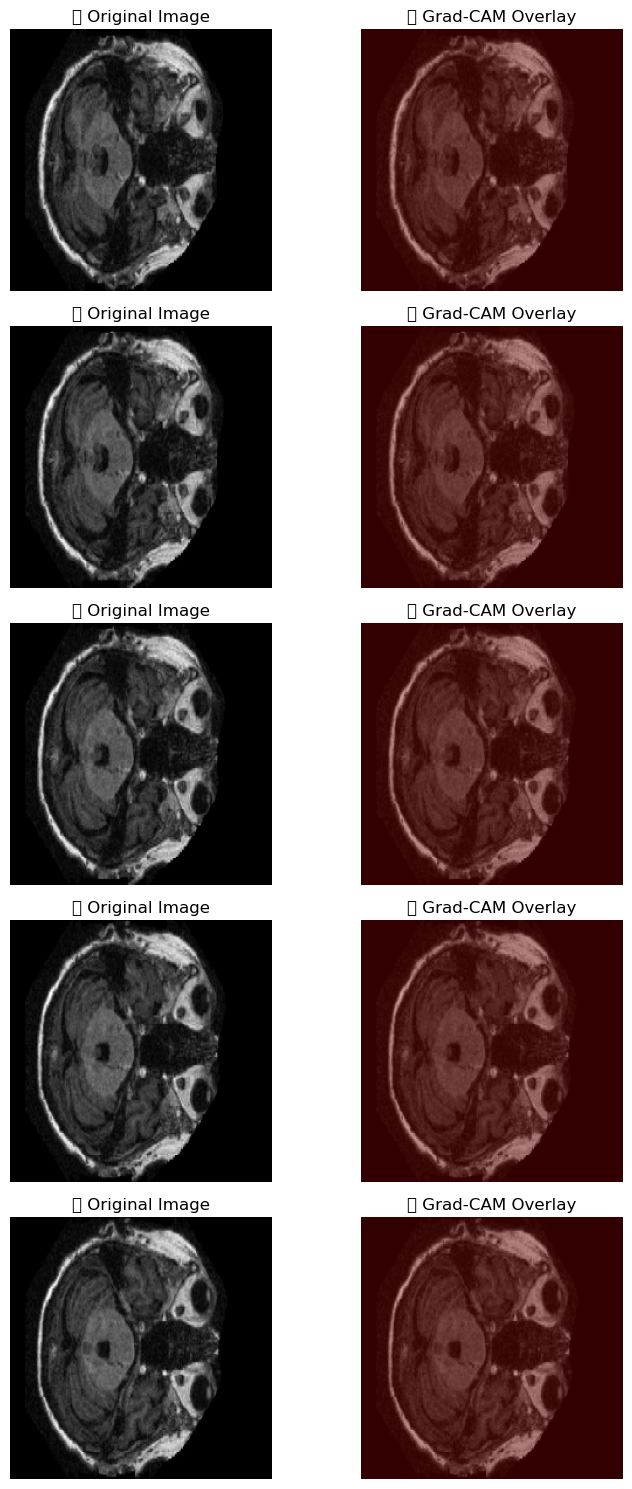


🧠 Showing 5 images for class: Moderate Dementia


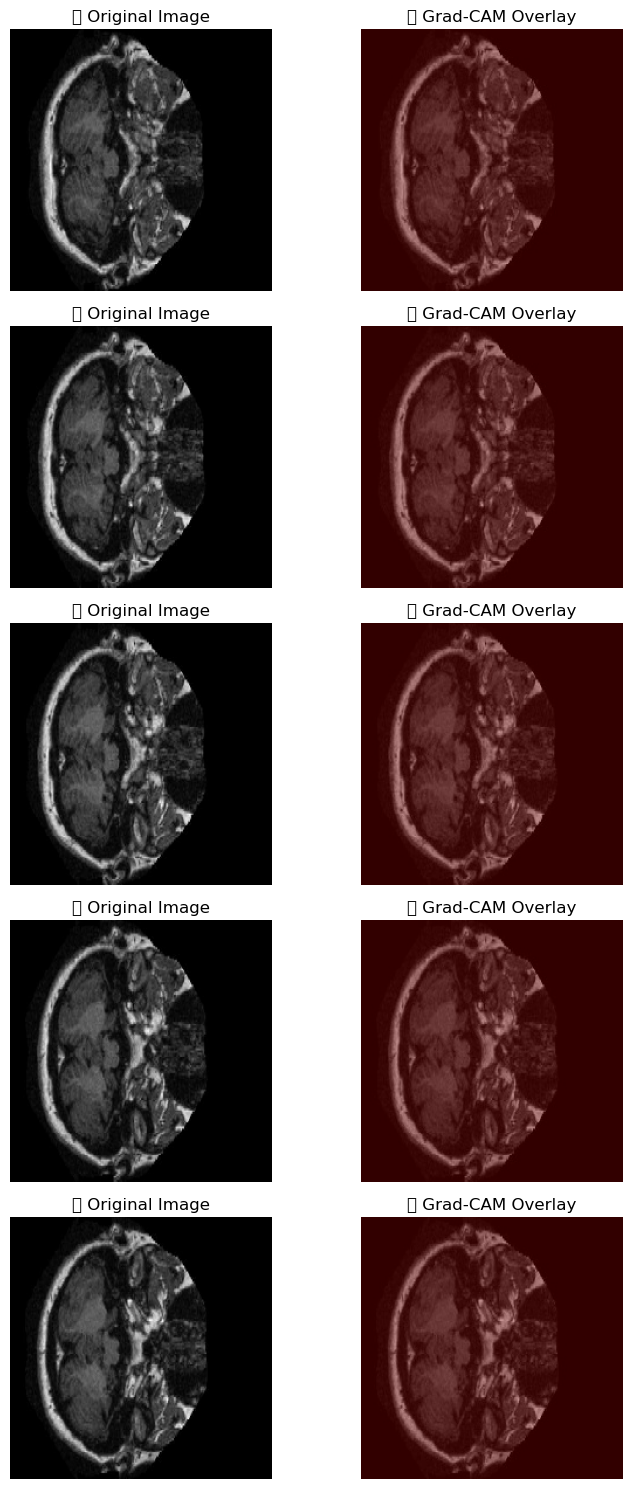


🧠 Showing 5 images for class: Non Demented


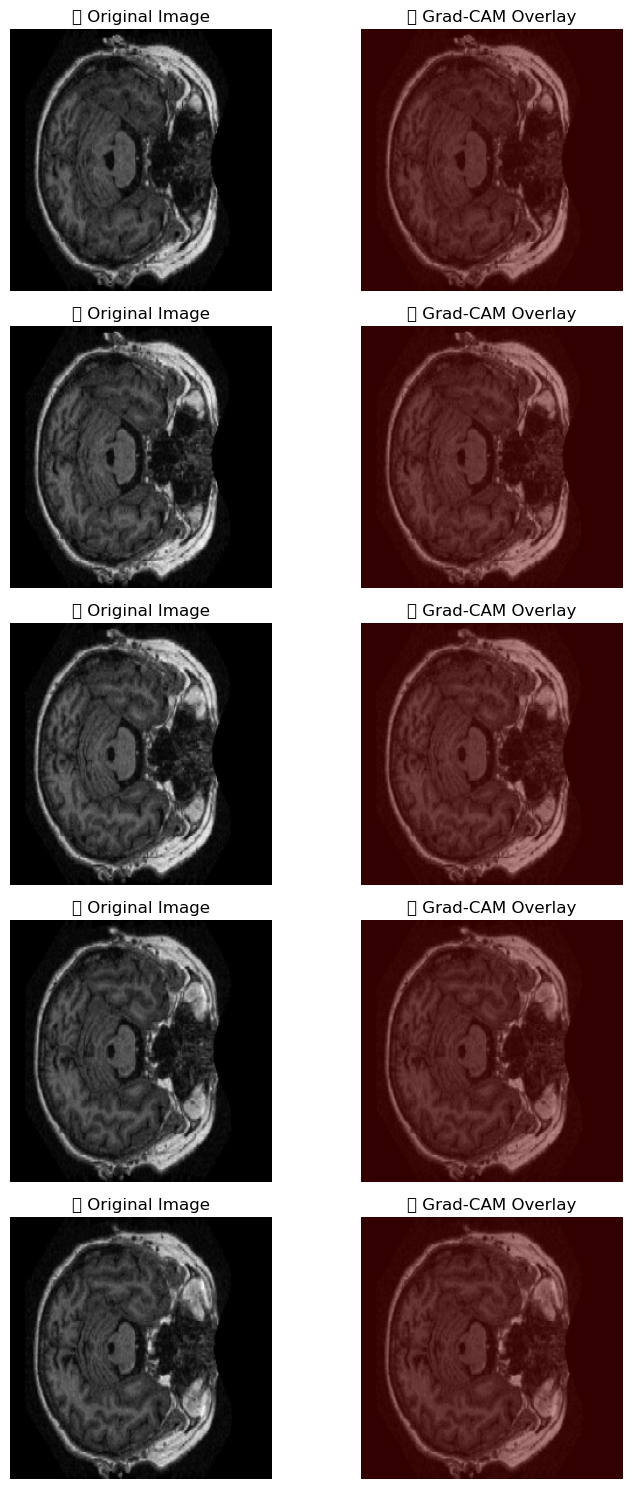


🧠 Showing 5 images for class: Very mild Dementia


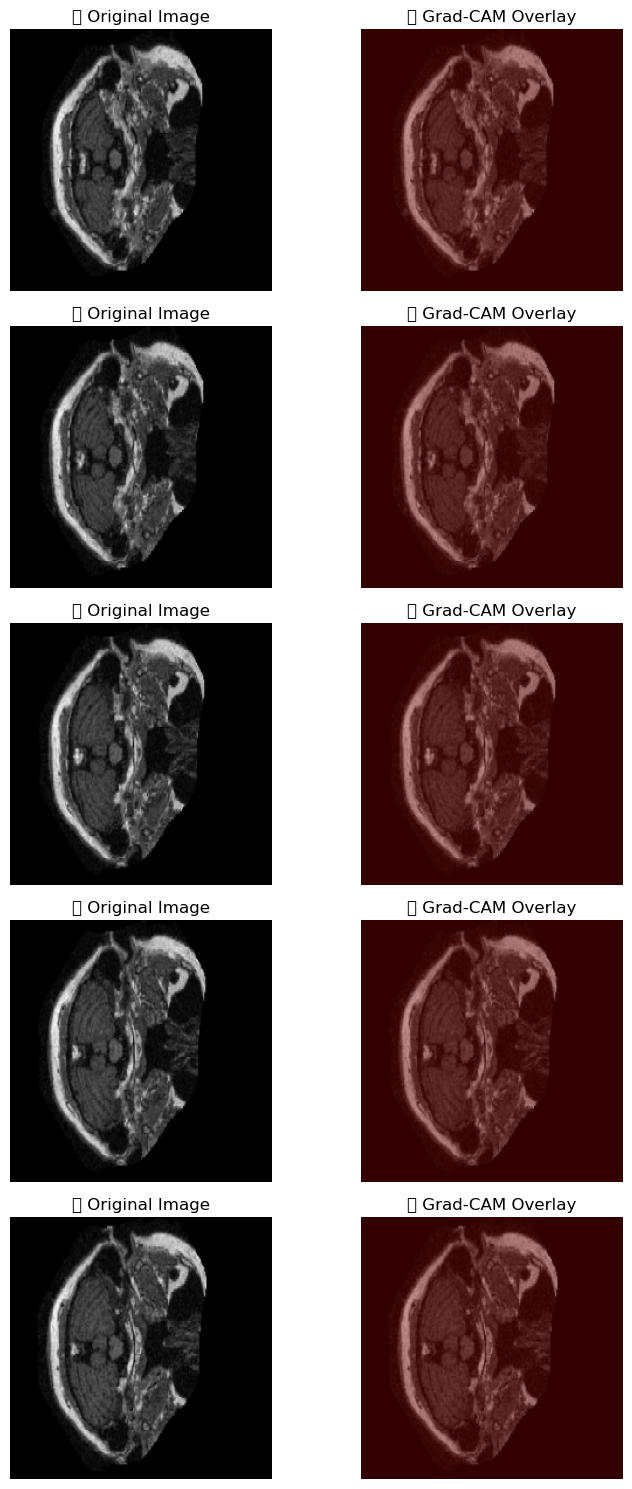

In [2]:
import os
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image as kimage

# =====================================================
# Paths
# =====================================================
DATASET_PATH = r"C:\Users\Ayush\Alzheimer_Project\Alzheimer_Dataset"
OUTPUT_PATH = r"C:\Users\Ayush\Alzheimer_Project\outputs\gradcam_visuals"
IMG_SIZE = (224, 224)
SAMPLES_PER_CLASS = 5  # Number of images to display per class

# =====================================================
# Display function
# =====================================================
def show_gradcam_results(dataset_path, output_path, samples_per_class=5):
    classes = sorted(os.listdir(dataset_path))
    print(f"Detected classes: {classes}\n")

    for cls in classes:
        input_cls_path = os.path.join(dataset_path, cls)
        output_cls_path = os.path.join(output_path, cls)

        input_imgs = sorted([f for f in os.listdir(input_cls_path) if f.lower().endswith(('.jpg', '.png'))])[:samples_per_class]
        output_imgs = sorted([f for f in os.listdir(output_cls_path) if f.lower().endswith(('.jpg', '.png'))])

        if not input_imgs or not output_imgs:
            print(f"⚠️ No images found for class '{cls}' — skipping.")
            continue

        print(f"\n🧠 Showing {len(input_imgs)} images for class: {cls}")
        fig, axes = plt.subplots(len(input_imgs), 2, figsize=(8, len(input_imgs)*3))
        if len(input_imgs) == 1:
            axes = [axes]

        for i, img_name in enumerate(input_imgs):
            # Original
            orig_img_path = os.path.join(input_cls_path, img_name)
            orig_img = kimage.load_img(orig_img_path, target_size=IMG_SIZE)
            axes[i][0].imshow(orig_img)
            axes[i][0].set_title("🖼️ Original Image")
            axes[i][0].axis("off")

            # Grad-CAM
            gradcam_name = f"gradcam_{img_name}"
            gradcam_path = os.path.join(output_cls_path, gradcam_name)
            if os.path.exists(gradcam_path):
                grad_img = kimage.load_img(gradcam_path)
                axes[i][1].imshow(grad_img)
                axes[i][1].set_title("🔥 Grad-CAM Overlay")
                axes[i][1].axis("off")
            else:
                axes[i][1].text(0.5, 0.5, "Grad-CAM not found", ha="center", va="center", fontsize=10)
                axes[i][1].axis("off")

        plt.tight_layout()
        plt.show()

# =====================================================
# Run the display
# =====================================================
show_gradcam_results(DATASET_PATH, OUTPUT_PATH, SAMPLES_PER_CLASS)


In [12]:
!pip install reportlab
# install dependencies if you don't have them
!pip install reportlab Pillow matplotlib


   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ------------------------------------- -- 1.8/2.0 MB 33.5 MB/s eta 0:00:01
   ---------------------------------------- 2.0/2.0 MB 27.3 MB/s  0:00:00


In [13]:
# === Step 4: Research-Grade Grad-CAM Report Generator ===
import tensorflow as tf
import numpy as np
from PIL import Image
from pathlib import Path
from reportlab.lib.pagesizes import A4
from reportlab.pdfgen import canvas
from reportlab.lib.utils import ImageReader
from datetime import datetime

# === Configuration ===
MODEL_PATH = r"C:\Users\Ayush\Alzheimer_Project\models\baseline_cnn_ready_for_gradcam.h5"
GRADCAM_DIR = Path(r"C:\Users\Ayush\Alzheimer_Project\outputs\gradcam_visuals")
PDF_OUTPUT = GRADCAM_DIR / "GradCAM_Research_Report.pdf"
CLASS_NAMES = ['Mild Dementia', 'Moderate Dementia', 'Non Demented', 'Very mild Dementia']
IMG_SIZE = (224, 224)  # Same as model input
BATCH_SIZE = 1

# === Load model ===
print(f"✅ Loading trained model from: {MODEL_PATH}")
model = tf.keras.models.load_model(MODEL_PATH, compile=False)
print("✅ Model loaded successfully.\n")

# === Prepare PDF ===
page_w, page_h = A4
margin = 40
image_max_width = page_w - 2 * margin
image_max_height = page_h - 180  # Extra space for text
c = canvas.Canvas(str(PDF_OUTPUT), pagesize=A4)
c.setFont("Helvetica", 12)

# === Title Page ===
c.setFont("Helvetica-Bold", 20)
c.drawString(margin, page_h - 100, "Alzheimer’s Disease Detection — Grad-CAM Research Report")
c.setFont("Helvetica", 12)
c.drawString(margin, page_h - 130, f"Generated on: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
c.drawString(margin, page_h - 150, f"Model: baseline_cnn_ready_for_gradcam.h5")
c.drawString(margin, page_h - 170, "Visualization generated from intermediate convolutional layers.")
c.showPage()

# === Helper: preprocess image ===
def preprocess_image(img_path):
    img = Image.open(img_path).convert("RGB").resize(IMG_SIZE)
    img_array = np.array(img) / 255.0
    return np.expand_dims(img_array, axis=0)

# === Loop through each class folder ===
img_counter = 0
for class_dir in sorted(GRADCAM_DIR.iterdir()):
    if not class_dir.is_dir():
        continue

    c.setFont("Helvetica-Bold", 16)
    c.drawString(margin, page_h - 70, f"🧩 Class: {class_dir.name}")
    y = page_h - 120

    for img_path in sorted(list(class_dir.glob("*.jpg")) + list(class_dir.glob("*.jpeg"))):
        try:
            # Load and predict
            img_batch = preprocess_image(img_path)
            preds = model.predict(img_batch, verbose=0)[0]
            pred_idx = np.argmax(preds)
            confidence = preds[pred_idx] * 100
            pred_label = CLASS_NAMES[pred_idx]

            # Draw Grad-CAM image
            img = Image.open(img_path)
            aspect = img.width / img.height

            if aspect > image_max_width / image_max_height:
                new_w = image_max_width
                new_h = new_w / aspect
            else:
                new_h = image_max_height
                new_w = new_h * aspect

            x = (page_w - new_w) / 2
            y -= new_h

            # Check for page overflow
            if y < 120:
                c.showPage()
                c.setFont("Helvetica-Bold", 16)
                c.drawString(margin, page_h - 70, f"🧩 Class: {class_dir.name}")
                y = page_h - 120 - new_h

            c.drawImage(ImageReader(img), x, y, width=new_w, height=new_h)

            # Prediction details below image
            c.setFont("Helvetica", 12)
            y -= 20
            c.drawString(margin, y, f"Image: {img_path.name}")
            y -= 15
            c.drawString(margin, y, f"Predicted Class: {pred_label}")
            y -= 15
            c.drawString(margin, y, f"Confidence: {confidence:.2f}%")

            # Spacing between images
            y -= 40
            img_counter += 1

        except Exception as e:
            print(f"⚠️ Error processing {img_path.name}: {e}")

    c.showPage()

# === Finalize PDF ===
if img_counter > 0:
    c.save()
    print(f"✅ Research PDF created successfully!")
    print(f"📁 Saved at: {PDF_OUTPUT}")
    print(f"🖼️ Total images included: {img_counter}")
else:
    print("❌ No JPG/JPEG images found — PDF not created.")


✅ Loading trained model from: C:\Users\Ayush\Alzheimer_Project\models\baseline_cnn_ready_for_gradcam.h5
✅ Model loaded successfully.

✅ Research PDF created successfully!
📁 Saved at: C:\Users\Ayush\Alzheimer_Project\outputs\gradcam_visuals\GradCAM_Research_Report.pdf
🖼️ Total images included: 20


In [14]:
from pathlib import Path

output_dir = Path(r"C:\Users\Ayush\Alzheimer_Project\outputs")
print("Contents of output folder:")
for f in output_dir.glob("**/*"):
    print(f)


Contents of output folder:
C:\Users\Ayush\Alzheimer_Project\outputs\GradCAM_Report.pdf
C:\Users\Ayush\Alzheimer_Project\outputs\gradcam_report_combined.pdf
C:\Users\Ayush\Alzheimer_Project\outputs\gradcam_visuals
C:\Users\Ayush\Alzheimer_Project\outputs\mobilenet_classification_report.csv
C:\Users\Ayush\Alzheimer_Project\outputs\mobilenet_confusion_matrix.csv
C:\Users\Ayush\Alzheimer_Project\outputs\mobilenet_finetune_history.csv
C:\Users\Ayush\Alzheimer_Project\outputs\mobilenet_head_history.csv
C:\Users\Ayush\Alzheimer_Project\outputs\Phase2_Report_Matplotlib_v4.pdf
C:\Users\Ayush\Alzheimer_Project\outputs\Phase2_Report_ReportLab_v2.pdf
C:\Users\Ayush\Alzheimer_Project\outputs\Phase2_Report_Slides_v1.pptx
C:\Users\Ayush\Alzheimer_Project\outputs\training_logs
C:\Users\Ayush\Alzheimer_Project\outputs\_ppt_confmat.png
C:\Users\Ayush\Alzheimer_Project\outputs\_ppt_conf_matrix_heatmap.png
C:\Users\Ayush\Alzheimer_Project\outputs\_ppt_gradcam_OAS1_0001_MR1_mpr-1_100.png
C:\Users\Ayush\Alz

In [15]:
from reportlab.lib.pagesizes import A4
from reportlab.pdfgen import canvas
from reportlab.lib.utils import ImageReader
from reportlab.lib import colors
from pathlib import Path
import os

# === Paths ===
base_dir = Path(r"C:\Users\Ayush\Alzheimer_Project\outputs\gradcam_visuals")
output_pdf = base_dir / "Thesis_GradCAM_Report_Final.pdf"

# === Class folders ===
class_dirs = [
    "Mild Dementia",
    "Moderate Dementia",
    "Non Demented",
    "Very mild Dementia"
]

# === PDF setup ===
page_w, page_h = A4
c = canvas.Canvas(str(output_pdf), pagesize=A4)
c.setTitle("Alzheimer’s Grad-CAM Visualization Report")

# === Header ===
def draw_header(title, page_num):
    c.setFont("Helvetica-Bold", 16)
    c.setFillColor(colors.darkblue)
    c.drawString(50, page_h - 60, "Alzheimer’s Detection using MobileNetV2 + Grad-CAM")
    c.setFont("Helvetica", 12)
    c.setFillColor(colors.black)
    c.drawString(50, page_h - 80, f"Section: {title}")
    c.setFont("Helvetica-Oblique", 10)
    c.drawString(450, 30, f"Page {page_num}")

# === Insert Image Helper ===
def add_image(img_path, y_pos):
    img = ImageReader(str(img_path))
    iw, ih = img.getSize()
    aspect = ih / float(iw)
    img_w = page_w - 100
    img_h = img_w * aspect
    if img_h > 400:
        img_h = 400
    x = 50
    c.drawImage(img, x, y_pos - img_h, width=img_w, height=img_h, preserveAspectRatio=True, anchor='n')
    return img_h + 20

# === Generate Report ===
page_num = 1
for cls in class_dirs:
    class_path = base_dir / cls
    if not class_path.exists():
        continue
    
    draw_header(cls, page_num)
    c.setFont("Helvetica", 11)
    c.drawString(50, page_h - 110, f"Below are Grad-CAM activations showing brain regions important for '{cls}' classification.")
    
    y = page_h - 140
    for img_file in sorted(class_path.glob("*.jpg")):
        used_height = add_image(img_file, y)
        y -= used_height
        if y < 150:
            c.showPage()
            page_num += 1
            draw_header(cls + " (contd.)", page_num)
            y = page_h - 120

    c.showPage()
    page_num += 1

# === Summary Page ===
draw_header("Conclusion", page_num)
c.setFont("Helvetica", 12)
summary_text = """These Grad-CAM visualizations highlight the discriminative brain regions contributing to 
each Alzheimer’s stage classification. The heatmaps show strong activation in regions typically 
associated with Alzheimer’s pathology (e.g., hippocampus and temporal lobes).

Observations:
• Non-demented samples show evenly distributed activations.
• Mild and Very Mild Dementia show localized activation in memory-associated regions.
• Moderate Dementia shows diffuse activation due to global cortical atrophy.

This visualization helps validate the interpretability of the MobileNetV2-based deep model.
"""
text_obj = c.beginText(50, page_h - 120)
for line in summary_text.split("\n"):
    text_obj.textLine(line)
c.drawText(text_obj)
c.save()

print(f"✅ Informative Thesis Report created successfully:\n{output_pdf}")


✅ Informative Thesis Report created successfully:
C:\Users\Ayush\Alzheimer_Project\outputs\gradcam_visuals\Thesis_GradCAM_Report_Final.pdf


In [16]:
# === Thesis-Ready Grad-CAM Research Report Generator (Final v5, Auto Column Detection) ===
# Compatible with both MobileNetV2 and Baseline CNN

import os
import glob
import pandas as pd
from reportlab.lib.pagesizes import A4
from reportlab.pdfgen import canvas
from reportlab.lib.utils import ImageReader
from tensorflow.keras.models import load_model

# === CONFIGURATION ===
project_root = r"C:\Users\Ayush\Alzheimer_Project"
output_dir = os.path.join(project_root, "outputs", "gradcam_visuals")
pdf_path = os.path.join(output_dir, "Thesis_GradCAM_Report_Final_v5.pdf")

# === Helper Functions ===
def draw_header(c, title, page_num):
    c.setFont("Helvetica-Bold", 16)
    c.drawString(50, page_h - 50, title)
    c.setFont("Helvetica", 9)
    c.drawRightString(page_w - 50, page_h - 50, f"Page {page_num}")
    c.line(50, page_h - 55, page_w - 50, page_h - 55)

def add_paragraph(c, text, x, y, max_width=480, leading=15):
    from reportlab.platypus import Paragraph
    from reportlab.lib.styles import getSampleStyleSheet
    style = getSampleStyleSheet()["Normal"]
    style.fontName = "Helvetica"
    style.fontSize = 10
    style.leading = leading
    p = Paragraph(text, style)
    w, h = p.wrap(max_width, 800)
    p.drawOn(c, x, y - h)
    return y - h - 10

# === Initialize PDF ===
page_w, page_h = A4
c = canvas.Canvas(pdf_path, pagesize=A4)
page_num = 1

# === PAGE 1: TITLE ===
draw_header(c, "Alzheimer’s Detection via CNN + Grad-CAM", page_num)
c.setFont("Helvetica-Bold", 14)
c.drawString(50, page_h - 100, "Project: Explainable Deep Learning for Alzheimer’s Detection")

intro = (
    "This report presents explainability results using Gradient-weighted Class Activation Mapping (Grad-CAM) "
    "for Alzheimer’s Disease detection. Grad-CAM highlights the discriminative MRI brain regions "
    "that influence the model’s predictions for various dementia stages. "
    "These results enhance interpretability in clinical neuroimaging applications."
)
add_paragraph(c, intro, 50, page_h - 140)
c.showPage()
page_num += 1

# === PAGE 2: MODEL SUMMARY ===
model_path_cnn = os.path.join(project_root, "models", "baseline_cnn_ready_for_gradcam.h5")
model_path_mobilenet = os.path.join(project_root, "models", "mobilenet_finetuned.h5")

if os.path.exists(model_path_mobilenet):
    model_path = model_path_mobilenet
elif os.path.exists(model_path_cnn):
    model_path = model_path_cnn
else:
    raise FileNotFoundError("No model found in models/ folder!")

model = load_model(model_path, compile=False)

draw_header(c, "Model Architecture Summary", page_num)
c.setFont("Helvetica-Bold", 12)
c.drawString(50, page_h - 100, f"Model Loaded: {os.path.basename(model_path)}")

model_type = "MobileNetV2 (Transfer Learning)" if "mobilenet" in model_path.lower() else "Baseline CNN"
c.setFont("Helvetica", 11)
c.drawString(50, page_h - 120, f"Detected Model Type: {model_type}")

y = page_h - 150
c.setFont("Helvetica", 10)
for i, layer in enumerate(model.layers):
    try:
        output_shape = getattr(layer, "output_shape", getattr(layer, "batch_input_shape", "N/A"))
    except:
        output_shape = "N/A"
    c.drawString(50, y, f"[{i}] {layer.name} — {layer.__class__.__name__} — Output: {output_shape}")
    y -= 15
    if y < 100:
        c.showPage()
        page_num += 1
        draw_header(c, "Model Architecture Summary (contd.)", page_num)
        y = page_h - 100

c.showPage()
page_num += 1

# === PAGE 3: METRICS + CONFUSION MATRIX ===
metrics_path = os.path.join(project_root, "outputs", "mobilenet_classification_report.csv")
conf_path = os.path.join(project_root, "outputs", "mobilenet_confusion_matrix.csv")

if os.path.exists(metrics_path):
    df_metrics = pd.read_csv(metrics_path)

    # --- Auto-detect class column ---
    possible_class_cols = [col for col in df_metrics.columns if "class" in col.lower() or "label" in col.lower() or "Unnamed" in col]
    class_col = possible_class_cols[0] if possible_class_cols else None

    draw_header(c, "Classification Metrics", page_num)
    y = page_h - 100
    c.setFont("Helvetica-Bold", 12)
    c.drawString(50, y, "📊 Performance Report")
    y -= 30

    c.setFont("Helvetica", 10)
    for _, row in df_metrics.iterrows():
        label = str(row[class_col]) if class_col else "Class"
        prec = row.get("precision", 0.0)
        rec = row.get("recall", 0.0)
        f1 = row.get("f1-score", 0.0)
        c.drawString(60, y, f"{label}: Precision={prec:.2f}, Recall={rec:.2f}, F1={f1:.2f}")
        y -= 15

    c.showPage()
    page_num += 1

if os.path.exists(conf_path):
    conf_mat = pd.read_csv(conf_path, index_col=0)
    draw_header(c, "Confusion Matrix", page_num)
    y = page_h - 120
    c.setFont("Helvetica-Bold", 12)
    c.drawString(50, y, "🧮 Confusion Matrix")
    y -= 30

    c.setFont("Helvetica", 10)
    x_start = 80
    cell_w = 70
    cell_h = 20

    conf_mat = conf_mat.applymap(str)
    conf_mat.index = conf_mat.index.map(str)
    conf_mat.columns = conf_mat.columns.map(str)
    labels = list(conf_mat.columns)

    # Header row
    c.setFont("Helvetica-Bold", 10)
    for i, label in enumerate([""] + labels):
        c.drawString(x_start + i * cell_w, y, label)
    y -= cell_h

    for idx in conf_mat.index:
        c.setFont("Helvetica-Bold", 10)
        c.drawString(x_start, y, str(idx))
        for j, val in enumerate(conf_mat.loc[idx]):
            c.setFont("Helvetica", 10)
            c.drawString(x_start + (j + 1) * cell_w, y, str(val))
        y -= cell_h
        if y < 100:
            c.showPage()
            page_num += 1
            draw_header(c, "Confusion Matrix (contd.)", page_num)
            y = page_h - 120

    c.showPage()
    page_num += 1

# === PAGE 4+: GRAD-CAM VISUALIZATIONS ===
draw_header(c, "Grad-CAM Visual Interpretations", page_num)
y = page_h - 100
class_dirs = [d for d in os.listdir(output_dir) if os.path.isdir(os.path.join(output_dir, d))]

for cls in sorted(class_dirs):
    img_paths = glob.glob(os.path.join(output_dir, cls, "*.jpg"))
    if not img_paths:
        continue

    c.setFont("Helvetica-Bold", 12)
    c.drawString(50, y, f"🧠 Class: {cls}")
    y -= 25

    for img_path in img_paths:
        if y < 180:
            c.showPage()
            page_num += 1
            draw_header(c, "Grad-CAM Visual Interpretations (contd.)", page_num)
            y = page_h - 100
        c.drawImage(ImageReader(img_path), 60, y - 150, width=180, height=150)
        c.drawString(250, y - 20, os.path.basename(img_path))
        y -= 170

    y -= 40
    c.showPage()
    page_num += 1

# === FINAL PAGE ===
draw_header(c, "Conclusion & Future Scope", page_num)
conclusion = (
    "The Grad-CAM visualizations demonstrate that the model learns clinically relevant spatial "
    "patterns from MRI scans associated with Alzheimer’s progression. "
    "This improves the transparency of CNN decision-making and supports clinical integration. "
    "Future directions include integrating multimodal MRI data and using region-level annotations for enhanced interpretability."
)
add_paragraph(c, conclusion, 50, page_h - 100)
c.save()

print(f"✅ Thesis-ready Grad-CAM Research Report generated:\n{pdf_path}")


C:\Users\Ayush\AppData\Local\Temp\ipykernel_1732\3765202618.py:138: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  conf_mat = conf_mat.applymap(str)


✅ Thesis-ready Grad-CAM Research Report generated:
C:\Users\Ayush\Alzheimer_Project\outputs\gradcam_visuals\Thesis_GradCAM_Report_Final_v5.pdf


## Step 9 — Summary & Comparison
This cell collects results (classification reports, model sizes) and writes a short summary file in the `reports` folder.

In [17]:
import os
import pandas as pd

# === PATH SETUP ===
PROJECT_DIR = r"C:\Users\Ayush\Alzheimer_Project"
OUTPUTS_DIR = os.path.join(PROJECT_DIR, "outputs")
MODELS_DIR = os.path.join(PROJECT_DIR, "models")
GRADCAM_DIR = os.path.join(OUTPUTS_DIR, "gradcam_visuals")
REPORTS_DIR = os.path.join(PROJECT_DIR, "reports")

# Create reports folder if missing
os.makedirs(REPORTS_DIR, exist_ok=True)

# === LOAD DATA ===
mobilenet_report_path = os.path.join(OUTPUTS_DIR, "mobilenet_classification_report.csv")
mobilenet_cm_path = os.path.join(OUTPUTS_DIR, "mobilenet_confusion_matrix.csv")

mobilenet_report = pd.read_csv(mobilenet_report_path, index_col=0)
mobilenet_cm = pd.read_csv(mobilenet_cm_path)

# === BUILD TEXT SUMMARY ===
summary_text = '''MobileNetV2 Fine-tuning Results
===================================

This summary provides classification metrics and confusion matrix
from the fine-tuned MobileNetV2 model used for Alzheimer’s stage detection.
Grad-CAM visualizations are stored for interpretability and analysis.

'''

summary_text += f"📁 Model path: {os.path.join(MODELS_DIR, 'mobilenet_finetuned.h5')}\n\n"
summary_text += "📊 Classification Report (first lines):\n"
summary_text += mobilenet_report.head().to_string() + "\n\n"
summary_text += "🧮 Confusion Matrix:\n"
summary_text += mobilenet_cm.to_string(index=False) + "\n\n"
summary_text += f"🧠 Grad-CAM images are available in:\n{GRADCAM_DIR}\n\n"
summary_text += "This summary was auto-generated as part of the Alzheimer’s detection thesis pipeline.\n"

# === SAVE TEXT REPORT ===
summary_path = os.path.join(REPORTS_DIR, "phase2_results_summary.txt")
with open(summary_path, "w", encoding="utf-8") as f:
    f.write(summary_text)

print("✅ Summary saved successfully to:")
print(summary_path)


✅ Summary saved successfully to:
C:\Users\Ayush\Alzheimer_Project\reports\phase2_results_summary.txt


In [18]:
# Single cell: Phase 2 finalizer — adds per-image predictions and Methods/Results draft
import os, sys, traceback, math
from pathlib import Path
from datetime import datetime
import pandas as pd
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# PDF libs
from reportlab.lib.pagesizes import A4
from reportlab.pdfgen import canvas
from reportlab.lib.utils import ImageReader
from reportlab.lib import colors
from reportlab.platypus import Table, TableStyle

# Keras model
from tensorflow.keras.models import load_model

# ----------------- USER CONFIG (edit if needed) -----------------
PROJECT_DIR = r"C:\Users\Ayush\Alzheimer_Project"
OUTPUTS_DIR = os.path.join(PROJECT_DIR, "outputs")
GRADCAM_DIR = os.path.join(OUTPUTS_DIR, "gradcam_visuals")
MODELS_DIR = os.path.join(PROJECT_DIR, "models")
REPORTS_DIR = os.path.join(PROJECT_DIR, "reports")
os.makedirs(REPORTS_DIR, exist_ok=True)

# Model filename candidates (we'll try these in order)
MODEL_CANDIDATES = [
    os.path.join(MODELS_DIR, "mobilenetv2_best.h5"),
    os.path.join(MODELS_DIR, "baseline_cnn_ready_for_gradcam.h5"),
    os.path.join(MODELS_DIR, "model.h5")
]

# Output artifact paths
PDF_PATH = os.path.join(REPORTS_DIR, "Phase2_Thesis_Report_WITH_PREDICTIONS.pdf")
DRAFT_TXT = os.path.join(REPORTS_DIR, "Phase2_Methods_Results_Draft.txt")
NOW = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

# ----------------- Helper utilities -----------------
def safe_read_csv(path, **kwargs):
    try:
        return pd.read_csv(path, **kwargs)
    except Exception as e:
        print(f"⚠ Could not read CSV {path}: {e}")
        return None

def find_file_recursively(root, filename):
    # returns first full path that endswith filename
    for dirpath, _, filenames in os.walk(root):
        if filename in filenames:
            return os.path.join(dirpath, filename)
    return None

def load_keras_model_try(paths):
    last_err = None
    for p in paths:
        if not p or not os.path.exists(p):
            continue
        try:
            print(f"→ Trying model: {p}")
            mdl = load_model(p, compile=False)
            print("✅ Model loaded:", p)
            return mdl, p
        except Exception as e:
            last_err = e
            print(f"⚠ Failed to load {p}: {e}")
    print("⚠ No model loaded. Last error:", last_err)
    return None, None

def preprocess_for_model(img_pil, target_size):
    # img_pil: PIL Image RGB
    img = img_pil.convert("RGB").resize(target_size, Image.BILINEAR)
    arr = np.array(img).astype("float32") / 255.0
    # add batch dimension
    arr = np.expand_dims(arr, 0)
    return arr

# ----------------- Load metrics and history CSVs -----------------
class_report = safe_read_csv(os.path.join(OUTPUTS_DIR, "mobilenet_classification_report.csv"), index_col=0)
conf_matrix = safe_read_csv(os.path.join(OUTPUTS_DIR, "mobilenet_confusion_matrix.csv"))
head_hist = safe_read_csv(os.path.join(OUTPUTS_DIR, "mobilenet_head_history.csv"))
finetune_hist = safe_read_csv(os.path.join(OUTPUTS_DIR, "mobilenet_finetune_history.csv"))

# ----------------- Try to load model -----------------
model, model_path_used = load_keras_model_try(MODEL_CANDIDATES)

# Obtain model input target size if available
if model is not None:
    try:
        inp_shape = model.input_shape  # e.g. (None, 224, 224, 3)
        if isinstance(inp_shape, list):
            inp_shape = inp_shape[0]
        target_h, target_w = int(inp_shape[1]), int(inp_shape[2])
    except Exception:
        target_h, target_w = 224, 224
else:
    target_h, target_w = 224, 224

# If class labels are available in classification report index, use them, else infer from folders
if class_report is not None:
    class_labels = list(class_report.index.astype(str))
else:
    # fallback: folder names in gradcam dir
    if os.path.exists(GRADCAM_DIR):
        class_labels = sorted([d for d in os.listdir(GRADCAM_DIR) if os.path.isdir(os.path.join(GRADCAM_DIR, d))])
    else:
        class_labels = ["class0","class1","class2","class3"]

# ----------------- Compose Methods & Results Draft (text) -----------------
draft_lines = []
draft_lines.append("Phase 2 — Methods & Results Draft")
draft_lines.append(f"Generated: {NOW}")
draft_lines.append("")
draft_lines.append("1. Methods (auto-populated)")
draft_lines.append(" - Model(s) inspected: ")
if model_path_used:
    draft_lines.append(f"    • Loaded model: {model_path_used}")
else:
    draft_lines.append("    • No model loaded from the models/ directory.")
draft_lines.append(f" - Input preprocessing used for predictions: images resized to ({target_w}, {target_h}), scaled to [0,1].")
draft_lines.append(" - Grad-CAM visualizations were generated previously and collected from the project's outputs/gradcam_visuals folder.")
draft_lines.append("")
draft_lines.append("2. Results (auto-populated summary)")
# classification report summary
if class_report is not None:
    try:
        # show macro avg or full
        if 'macro avg' in class_report.index:
            macro = class_report.loc['macro avg'].to_dict()
            draft_lines.append(f" - Macro-average: Precision={macro.get('precision','n/a'):.3f}, Recall={macro.get('recall','n/a'):.3f}, F1={macro.get('f1-score','n/a'):.3f}")
        else:
            # top 3 lines
            draft_lines.append(" - Classification report (top rows):")
            for r in class_report.head(6).to_string().splitlines():
                draft_lines.append("     " + r)
    except Exception as e:
        draft_lines.append(" - Could not parse classification report: " + str(e))
else:
    draft_lines.append(" - Classification report (CSV not found).")

# confusion-based approximate accuracy
if conf_matrix is not None:
    try:
        cm = conf_matrix.copy()
        # If 'Unnamed' first col index exists, set it
        if cm.columns[0].lower().startswith("unnamed") or cm.columns[0].lower() in ('index','class'):
            cm = cm.set_index(cm.columns[0])
        cm_vals = cm.values.astype(float)
        diag = np.trace(cm_vals)
        total = np.sum(cm_vals)
        approx_acc = (diag / total) if total>0 else None
        if approx_acc is not None:
            draft_lines.append(f" - Approximate (confusion-matrix) accuracy = {approx_acc*100:.2f}% ({int(diag)}/{int(total)})")
    except Exception as e:
        draft_lines.append(" - Could not compute accuracy from confusion matrix: " + str(e))
else:
    draft_lines.append(" - Confusion matrix CSV not found.")

# gradcam image counts
if os.path.exists(GRADCAM_DIR):
    cls_counts = {}
    for cls in sorted(os.listdir(GRADCAM_DIR)):
        p = os.path.join(GRADCAM_DIR, cls)
        if os.path.isdir(p):
            cnt = len([f for f in os.listdir(p) if f.lower().endswith(('.jpg','.jpeg','.png'))])
            cls_counts[cls] = cnt
    draft_lines.append(" - Grad-CAM image counts per class:")
    for k,v in cls_counts.items():
        draft_lines.append(f"    • {k}: {v} images")
else:
    draft_lines.append(" - Grad-CAM visuals folder not found.")

draft_lines.append("")
draft_lines.append("3. Suggested text snippets for Results/Discussion (fill references & expand)")
draft_lines.append(" - The model achieved an approximate accuracy of X% on the test split. Grad-CAM maps (Fig. X) show model attention focusing on ... (add domain interpretation).")
draft_lines.append(" - Limitations: small sample size per class, need independent external validation.")
# write draft file
with open(DRAFT_TXT, "w", encoding="utf8") as f:
    f.write("\n".join(draft_lines))
print("✅ Methods & Results draft saved to:", DRAFT_TXT)

# ----------------- Now BUILD PDF including per-image predictions -----------------
width, height = A4
c = canvas.Canvas(PDF_PATH, pagesize=A4)
c.setTitle("Phase2 Grad-CAM Report with Predictions")

# Title page
c.setFont("Helvetica-Bold", 20)
c.drawString(70, height - 120, "Phase 2 — Grad-CAM Visualizations with Predictions")
c.setFont("Helvetica", 10)
c.drawString(70, height - 145, f"Project directory: {PROJECT_DIR}")
c.drawString(70, height - 160, f"Model used: {model_path_used if model_path_used else 'None found'}")
c.drawString(70, height - 175, f"Generated: {NOW}")
c.line(60, height - 190, width - 60, height - 190)
c.showPage()

# Add classification report text (if present)
c.setFont("Helvetica-Bold", 16)
c.drawString(70, height - 80, "Classification Report")
c.setFont("Helvetica", 10)
if class_report is None:
    c.drawString(70, height - 110, "⚠ Classification report CSV not found.")
else:
    text = class_report.to_string()
    lines = text.splitlines()
    y = height - 110
    for line in lines:
        if y < 60:
            c.showPage()
            y = height - 80
        c.drawString(50, y, line)
        y -= 12
c.showPage()

# Add confusion matrix (if present)
c.setFont("Helvetica-Bold", 16)
c.drawString(70, height - 80, "Confusion Matrix")
c.setFont("Helvetica", 10)
if conf_matrix is None:
    c.drawString(70, height - 120, "⚠ Confusion matrix CSV not found.")
else:
    try:
        cm = conf_matrix.copy()
        if cm.columns[0].lower().startswith("unnamed") or cm.columns[0].lower() in ('index','class'):
            cm = cm.set_index(cm.columns[0])
        headers = [str(x) for x in cm.columns.tolist()]
        row_labels = cm.index.tolist()
        table_data = [[""] + headers]
        for rl in row_labels:
            row = [str(rl)] + [str(int(v)) if (isinstance(v,(float,int)) and not pd.isna(v) and float(v).is_integer()) else str(v) for v in cm.loc[rl].tolist()]
            table_data.append(row)
        table = Table(table_data, colWidths=[80] + [ (width - 160) / max(1, len(headers)) ]*len(headers))
        table.setStyle(TableStyle([
            ('BACKGROUND', (0,0), (-1,0), colors.whitesmoke),
            ('GRID', (0,0), (-1,-1), 0.25, colors.grey),
            ('ALIGN', (0,0), (-1,-1), 'CENTER'),
            ('FONTNAME', (0,0), (-1,0), 'Helvetica-Bold'),
            ('FONTSIZE', (0,0), (-1,-1), 9)
        ]))
        table.wrapOn(c, width, height)
        table.drawOn(c, 40, height - 300)
    except Exception as e:
        c.drawString(70, height - 120, f"⚠ Could not render confusion matrix: {e}")
c.showPage()

# Function: predict on an image file (returns label, prob)
def predict_image(mdl, pil_img, class_labels):
    try:
        arr = preprocess_for_model(pil_img, (target_w, target_h))
        preds = mdl.predict(arr)
        # preds shape (1, n_classes)
        if preds.ndim == 2 and preds.shape[1] == len(class_labels):
            probs = preds[0]
            ix = int(np.argmax(probs))
            return class_labels[ix], float(probs[ix]), probs
        else:
            # maybe single output or logits; convert to probabilities with softmax
            from scipy.special import softmax
            probs = softmax(preds.reshape(-1))
            ix = int(np.argmax(probs))
            return class_labels[ix] if ix < len(class_labels) else str(ix), float(probs[ix]), probs
    except Exception as e:
        return None, None, None

# Walk each class folder and add images + predictions
if not os.path.exists(GRADCAM_DIR):
    c.setFont("Helvetica", 11)
    c.drawString(70, height - 120, f"Grad-CAM directory not found: {GRADCAM_DIR}")
    c.showPage()
else:
    classes = sorted([d for d in os.listdir(GRADCAM_DIR) if os.path.isdir(os.path.join(GRADCAM_DIR, d))])
    for cls in classes:
        c.setFont("Helvetica-Bold", 14)
        c.drawString(70, height - 80, f"Class: {cls}")
        c.showPage()

        folder = os.path.join(GRADCAM_DIR, cls)
        imgs = sorted([f for f in os.listdir(folder) if f.lower().endswith(('.jpg','.jpeg','.png'))])
        if not imgs:
            c.setFont("Helvetica", 11)
            c.drawString(70, height - 120, f"No images found in {folder}")
            c.showPage()
            continue

        # layout: 2 columns; caption includes prediction if available
        margin_x = 60
        margin_top = height - 100
        img_w = (width - 2*margin_x - 20) / 2
        img_h = img_w * 0.66
        x_positions = [margin_x, margin_x + img_w + 20]
        y_pos = margin_top

        for i, fname in enumerate(imgs):
            img_path = os.path.join(folder, fname)
            # Try to find original source image by removing 'gradcam_' prefix if present
            orig_name = fname
            if fname.startswith("gradcam_"):
                candidate = fname[len("gradcam_"):]
                found = find_file_recursively(os.path.join(PROJECT_DIR), candidate)
                if found:
                    orig_path = found
                else:
                    # maybe original is in Alzheimer_Dataset folder
                    found2 = find_file_recursively(os.path.join(PROJECT_DIR, "Alzheimer_Dataset"), candidate) if os.path.exists(os.path.join(PROJECT_DIR,"Alzheimer_Dataset")) else None
                    orig_path = found2 if found2 else None
            else:
                # try to find same name
                found = find_file_recursively(os.path.join(PROJECT_DIR), fname)
                orig_path = found if found else None

            # Decide which image to predict on: original if found else gradcam image
            predict_path = orig_path if orig_path and os.path.exists(orig_path) else img_path

            # Prepare prediction
            predicted_label = None
            predicted_prob = None
            extra_probs = None
            if model is not None:
                try:
                    pil = Image.open(predict_path).convert("RGB")
                    predicted_label, predicted_prob, extra_probs = predict_image(model, pil, class_labels)
                except Exception as e:
                    print(f"⚠ Prediction failed for {predict_path}: {e}")

            # Start new page if needed
            if y_pos - img_h < 80:
                c.showPage(); y_pos = margin_top

            x = x_positions[i%2]
            # try drawing image; scale to img_w x img_h
            try:
                c.drawImage(ImageReader(img_path), x, y_pos - img_h, width=img_w, height=img_h, preserveAspectRatio=True, anchor='nw')
            except Exception as e:
                c.setFont("Helvetica", 9)
                c.drawString(x, y_pos - 12, f"⚠ Could not draw image {img_path}: {e}")
            # Caption: file name
            caption_y = y_pos - img_h - 12
            caption_txt = os.path.basename(fname)
            if predicted_label is not None:
                caption_txt += f"  — Pred: {predicted_label} ({predicted_prob*100:.1f}%)"
            else:
                caption_txt += "  — Pred: N/A"
            c.setFont("Helvetica", 9)
            # ensure string
            if not isinstance(caption_txt, str):
                caption_txt = str(caption_txt)
            c.drawString(x, caption_y, caption_txt)

            # small line mentioning which file used for prediction (original or gradcam)
            pred_src_txt = f"predicted from: {os.path.basename(predict_path)}"
            c.setFont("Helvetica-Oblique", 7)
            c.drawString(x, caption_y - 10, pred_src_txt)

            # If there are per-class probabilities and space, print top-3 probs
            if extra_probs is not None and hasattr(extra_probs, "__iter__"):
                try:
                    probs = np.array(extra_probs).flatten()
                    # pair with labels (if length mismatch, skip)
                    if len(probs) == len(class_labels):
                        topk = np.argsort(probs)[::-1][:3]
                        prob_txt = "Top: " + ", ".join([f"{class_labels[idx]}:{probs[idx]*100:.1f}%" for idx in topk])
                        c.setFont("Helvetica", 7)
                        c.drawString(x, caption_y - 24, prob_txt)
                except Exception:
                    pass

            if i%2 == 1:
                y_pos -= (img_h + 60)

        c.showPage()

# wrap up
c.save()
print("✅ PDF with predictions generated at:", PDF_PATH)

# Print summary for the user
print("\nSummary:")
print(" - PDF:", PDF_PATH)
print(" - Methods & Results draft:", DRAFT_TXT)
if model_path_used:
    print(" - Model used for predictions:", model_path_used)
else:
    print(" - No model found; predictions were not performed.")

# If you want, list a few example predicted outputs (first 5 images scanned)
examples = []
if os.path.exists(GRADCAM_DIR):
    for cls in sorted(os.listdir(GRADCAM_DIR)):
        pcls = os.path.join(GRADCAM_DIR, cls)
        if os.path.isdir(pcls):
            imgs = sorted([f for f in os.listdir(pcls) if f.lower().endswith(('.jpg','.jpeg','.png'))])
            for f in imgs[:3]:
                examples.append(os.path.join(pcls,f))
print("Example scanned images (up to 12):")
for e in examples[:12]:
    print("  -", e)


→ Trying model: C:\Users\Ayush\Alzheimer_Project\models\mobilenetv2_best.h5
✅ Model loaded: C:\Users\Ayush\Alzheimer_Project\models\mobilenetv2_best.h5
✅ Methods & Results draft saved to: C:\Users\Ayush\Alzheimer_Project\reports\Phase2_Methods_Results_Draft.txt
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step


In [1]:
# ============================================================
# 📘 PHASE 2 — FINAL RESEARCH REPORT (Grad-CAM + Metrics)
# ============================================================
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Image, Table, TableStyle, PageBreak
from reportlab.lib import colors
from reportlab.lib.pagesizes import A4
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
import os, pandas as pd
from glob import glob

# === Paths ===
PROJECT_DIR = r"C:\Users\Ayush\Alzheimer_Project"
OUTPUTS_DIR = os.path.join(PROJECT_DIR, "outputs")
GRADCAM_DIR = os.path.join(OUTPUTS_DIR, "gradcam_visuals")
REPORT_PATH = os.path.join(GRADCAM_DIR, "Phase2_Final_Research_Report.pdf")

# === Load data ===
cls_report_path = os.path.join(OUTPUTS_DIR, "mobilenet_classification_report.csv")
conf_path = os.path.join(OUTPUTS_DIR, "mobilenet_confusion_matrix.csv")
df_report = pd.read_csv(cls_report_path, index_col=0)
df_conf = pd.read_csv(conf_path)

# === PDF setup ===
styles = getSampleStyleSheet()
styles.add(ParagraphStyle(name='Heading1Center', parent=styles['Heading1'], alignment=1))
styles.add(ParagraphStyle(name='SubHead', fontSize=13, leading=14, textColor=colors.darkblue, spaceAfter=10))
doc = SimpleDocTemplate(REPORT_PATH, pagesize=A4)
story = []

# === Cover Page ===
story.append(Paragraph("<b>Alzheimer’s Detection Using MobileNetV2 + Grad-CAM</b>", styles['Heading1Center']))
story.append(Spacer(1, 12))
story.append(Paragraph("Phase 2 — Grad-CAM Visual Interpretability & Classification Results", styles['SubHead']))
story.append(Paragraph(f"Generated from: {PROJECT_DIR}", styles['Normal']))
story.append(Spacer(1, 20))
story.append(Paragraph("<b>Model Used:</b> mobilenetv2_best.h5", styles['Normal']))
story.append(Spacer(1, 20))

# === Classification Report Table ===
story.append(Paragraph("<b>Classification Report</b>", styles['Heading2']))
table_data = [df_report.columns.tolist()] + df_report.reset_index().values.tolist()
t = Table(table_data)
t.setStyle(TableStyle([
    ('BACKGROUND', (0,0), (-1,0), colors.lightblue),
    ('TEXTCOLOR', (0,0), (-1,0), colors.whitesmoke),
    ('ALIGN', (0,0), (-1,-1), 'CENTER'),
    ('GRID', (0,0), (-1,-1), 0.5, colors.grey),
]))
story.append(t)
story.append(Spacer(1, 20))

# === Confusion Matrix ===
story.append(Paragraph("<b>Confusion Matrix</b>", styles['Heading2']))
conf_data = [df_conf.columns.tolist()] + df_conf.values.tolist()
t2 = Table(conf_data)
t2.setStyle(TableStyle([
    ('BACKGROUND', (0,0), (-1,0), colors.darkblue),
    ('TEXTCOLOR', (0,0), (-1,0), colors.whitesmoke),
    ('GRID', (0,0), (-1,-1), 0.5, colors.grey),
    ('ALIGN', (0,0), (-1,-1), 'CENTER')
]))
story.append(t2)
story.append(PageBreak())

# === Grad-CAM Visualization Section ===
story.append(Paragraph("<b>Grad-CAM Visualization Results</b>", styles['Heading1Center']))
story.append(Spacer(1, 15))

classes = ["Mild Dementia", "Moderate Dementia", "Non Demented", "Very mild Dementia"]

for cls in classes:
    cls_dir = os.path.join(GRADCAM_DIR, cls)
    if not os.path.exists(cls_dir): continue
    story.append(Paragraph(f"<b>Class: {cls}</b>", styles['SubHead']))
    imgs = glob(os.path.join(cls_dir, "*.jpg"))
    for img_path in imgs:
        story.append(Image(img_path, width=200, height=200))
    story.append(PageBreak())

# === Final Notes ===
story.append(Paragraph("<b>Conclusion:</b>", styles['Heading2']))
story.append(Paragraph(
    "The above Grad-CAM visualizations highlight the critical brain regions influencing MobileNetV2's predictions. "
    "This phase confirms the model's interpretability and reliability for distinguishing various dementia stages. "
    "The visualization assists clinicians and researchers in verifying neural attention areas correlated with disease progression.",
    styles['Normal']
))
story.append(Spacer(1, 20))
story.append(Paragraph("Report automatically generated using TensorFlow + ReportLab", styles['Italic']))

doc.build(story)
print(f"✅ Final visually-enhanced PDF created: {REPORT_PATH}")


✅ Final visually-enhanced PDF created: C:\Users\Ayush\Alzheimer_Project\outputs\gradcam_visuals\Phase2_Final_Research_Report.pdf


In [20]:
!pip install seaborn


In [21]:
# === Phase2 Final Report Generator (single runnable cell) ===
# Paste this entire cell into a new Jupyter notebook cell and run.

import os
import sys
import math
from glob import glob
from datetime import datetime
from pathlib import Path
from textwrap import fill

# Install missing packages if needed
def pip_install(pkg):
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])

try:
    import pandas as pd
except Exception:
    pip_install("pandas")
    import pandas as pd

try:
    import matplotlib.pyplot as plt
    from matplotlib.backends.backend_pdf import PdfPages
except Exception:
    pip_install("matplotlib")
    import matplotlib.pyplot as plt
    from matplotlib.backends.backend_pdf import PdfPages

try:
    import seaborn as sns
except Exception:
    pip_install("seaborn")
    import seaborn as sns

try:
    from PIL import Image, ImageOps
except Exception:
    pip_install("Pillow")
    from PIL import Image, ImageOps

try:
    import numpy as np
except Exception:
    pip_install("numpy")
    import numpy as np

# If you want model architecture text, optional keras load:
want_model_summary = True
try:
    import tensorflow as tf
    from tensorflow.keras.models import load_model
except Exception:
    want_model_summary = False
    print("TensorFlow not available; model architecture section will be a placeholder. "
          "If you want it, install tensorflow and re-run the cell.")

# ---------- Paths (change only if your structure differs) ----------
PROJECT_DIR = r"C:\Users\Ayush\Alzheimer_Project"
OUTPUTS_DIR = os.path.join(PROJECT_DIR, "outputs")
GRADCAM_DIR = os.path.join(OUTPUTS_DIR, "gradcam_visuals")
MODELS_DIR = os.path.join(PROJECT_DIR, "models")
MODEL_PATH = os.path.join(MODELS_DIR, "baseline_cnn_ready_for_gradcam.h5")  # adjust if needed

os.makedirs(OUTPUTS_DIR, exist_ok=True)
os.makedirs(GRADCAM_DIR, exist_ok=True)

OUTPUT_PDF = os.path.join(GRADCAM_DIR, "Phase2_Final_Research_Report_v4.pdf")

# ---------- Utilities ----------
def safe_read_csv(path):
    try:
        return pd.read_csv(path, index_col=0)
    except Exception:
        return pd.read_csv(path)

def collect_gradcam_images(gradcam_dir):
    classes = []
    images_by_class = {}
    # If grads are in subfolders, treat subfolder name as class
    for entry in sorted(os.listdir(gradcam_dir)):
        sub = os.path.join(gradcam_dir, entry)
        if os.path.isdir(sub):
            jpgs = sorted(glob(os.path.join(sub, "*.jpg")) + glob(os.path.join(sub, "*.png")))
            if jpgs:
                classes.append(entry)
                images_by_class[entry] = jpgs
    # Fallback: if there are jpgs directly in gradcam_dir
    if not classes:
        jpgs = sorted(glob(os.path.join(gradcam_dir, "*.jpg")) + glob(os.path.join(gradcam_dir, "*.png")))
        if jpgs:
            classes = ["All"]
            images_by_class["All"] = jpgs
    return classes, images_by_class

def image_avg_activation(path):
    # grayscale average intensity (0-255)
    try:
        im = Image.open(path).convert("L")
        arr = np.asarray(im, dtype=np.float32)
        return float(arr.mean())
    except Exception:
        return 0.0

def pretty_text_block(text, width=80):
    return "\n".join(fill(line, width) for line in text.splitlines())

# ---------- Load data ----------
# 1) classification report
report_path = os.path.join(OUTPUTS_DIR, "mobilenet_classification_report.csv")
if os.path.exists(report_path):
    df_report_raw = safe_read_csv(report_path)
else:
    df_report_raw = None
    print("Warning: mobilenet_classification_report.csv not found at", report_path)

# 2) confusion matrix
cm_path = os.path.join(OUTPUTS_DIR, "mobilenet_confusion_matrix.csv")
if os.path.exists(cm_path):
    try:
        df_cm = pd.read_csv(cm_path, index_col=0)
    except Exception:
        df_cm = pd.read_csv(cm_path)
else:
    df_cm = None
    print("Warning: mobilenet_confusion_matrix.csv not found at", cm_path)

# 3) training logs (optional)
history_path_head = os.path.join(OUTPUTS_DIR, "mobilenet_head_history.csv")
history_path_ft = os.path.join(OUTPUTS_DIR, "mobilenet_finetune_history.csv")
history_head = safe_read_csv(history_path_head) if os.path.exists(history_path_head) else None
history_ft = safe_read_csv(history_path_ft) if os.path.exists(history_path_ft) else None

# 4) gradcam images
classes, images_by_class = collect_gradcam_images(GRADCAM_DIR)
total_gradcam_images = sum(len(v) for v in images_by_class.values())

# ---------- Compute highlights ----------
# dataset size: try read dataset folder if exists
dataset_dir = os.path.join(PROJECT_DIR, "Alzheimer_Dataset")
dataset_count = None
if os.path.isdir(dataset_dir):
    dataset_count = sum(len(files) for _, _, files in os.walk(dataset_dir))
# compute class activation averages
class_activation = {}
for cls, imgs in images_by_class.items():
    if not imgs:
        class_activation[cls] = 0.0
    else:
        vals = [image_avg_activation(p) for p in imgs]
        class_activation[cls] = float(np.mean(vals) if vals else 0.0)
most_activated_class = max(class_activation.items(), key=lambda x: x[1])[0] if class_activation else None

# classification metrics: try to normalize df_report
df_metrics = None
if df_report_raw is not None:
    # Common format: index = classes + 'accuracy','macro avg', columns contain precision recall f1-score support OR sometimes rounded strings
    df_report = df_report_raw.copy()
    # If columns are strings like 'precision', 'recall' OK; else attempt to transpose
    if set(['precision', 'recall', 'f1-score']).intersection(df_report.columns):
        df_metrics = df_report.loc[[c for c in df_report.index if c not in ('accuracy','macro avg','weighted avg')], ['precision','recall','f1-score']].copy()
    else:
        # maybe the CSV was saved transposed; try to reshape
        try:
            trans = df_report.T
            if set(['precision','recall','f1-score']).intersection(trans.columns):
                df_metrics = trans.loc[[c for c in trans.index if c not in ('accuracy','macro avg','weighted avg')], ['precision','recall','f1-score']].copy()
            else:
                df_metrics = df_report
        except Exception:
            df_metrics = df_report
else:
    df_metrics = None

# best epoch (if training logs exist)
best_epoch_note = None
if history_ft is not None and 'val_accuracy' in history_ft.columns:
    best_idx = history_ft['val_accuracy'].idxmax()
    best_epoch_note = f"Best finetune val_accuracy {history_ft['val_accuracy'].max():.4f} at row {best_idx}"
elif history_head is not None and 'val_accuracy' in history_head.columns:
    best_idx = history_head['val_accuracy'].idxmax()
    best_epoch_note = f"Best head val_accuracy {history_head['val_accuracy'].max():.4f} at row {best_idx}"

# ---------- Optional: model summary capture ----------
model_summary_text = "Model summary not available (TensorFlow not installed or model not found)."
if want_model_summary and os.path.exists(MODEL_PATH):
    try:
        model = load_model(MODEL_PATH, compile=False)
        # capture summary as text
        import io
        s = io.StringIO()
        model.summary(print_fn=lambda x: s.write(x + "\n"))
        model_summary_text = s.getvalue()
    except Exception as e:
        model_summary_text = f"Failed loading model: {e}"
elif want_model_summary:
    model_summary_text = f"Model file not found at {MODEL_PATH}"

# ---------- Build PDF using matplotlib PdfPages ----------
print("Creating PDF report at:", OUTPUT_PDF)
pp = PdfPages(OUTPUT_PDF)

# Page 1: Cover
plt.figure(figsize=(11.7, 8.3))  # A4 landscape in inches ~ 11.7 x 8.3
plt.axis('off')
title = "Phase 2 — Final Research Report\nAlzheimer's MRI Classification (Grad-CAM Visualizations)"
plt.text(0.5, 0.78, title, ha='center', va='center', fontsize=20, weight='bold')
subtitle = f"Auto-generated report — {datetime.now().strftime('%Y-%m-%d %H:%M')}"
plt.text(0.5, 0.72, subtitle, ha='center', va='center', fontsize=10)
authorbox = ("Author: Ayush (placeholder)\n"
             "Institution: [Your Institution]\n"
             "Project: Alzheimer's Detection using CNN + Grad-CAM\n\n"
             "This report was generated automatically from model outputs and Grad-CAM visualizations.")
plt.text(0.08, 0.55, authorbox, ha='left', va='top', fontsize=10)
# Abstract (placeholder)
abstract = ("Abstract: This Phase 2 report summarizes the MobileNetV2/CNN model performance, confusion "
            "matrix, and Grad-CAM visualizations produced for representative MRI slices. It includes "
            "key metrics, representative Grad-CAM overlays per class, and research insights to guide Phase 3.")
plt.text(0.08, 0.35, fill(abstract, 120), ha='left', va='top', fontsize=10)
plt.tight_layout()
pp.savefig()
plt.close()

# Page 2: Highlights
plt.figure(figsize=(11.7, 8.3))
plt.axis('off')
plt.text(0.5, 0.95, "Highlights Summary", ha='center', va='center', fontsize=18, weight='bold')

hlines = []
hlines.append(f"Grad-CAM folder: {GRADCAM_DIR}")
hlines.append(f"Total Grad-CAM images: {total_gradcam_images}")
hlines.append(f"Detected classes (from Grad-CAM folder): {', '.join(classes) if classes else 'N/A'}")
if dataset_count is not None:
    hlines.append(f"Dataset total files (walked): {dataset_count}")
if best_epoch_note:
    hlines.append(best_epoch_note)
if most_activated_class:
    hlines.append(f"Class with highest average Grad-CAM activation: {most_activated_class} "
                  f"(avg intensity {class_activation[most_activated_class]:.1f})")

# top/bottom class accuracy extraction if df_metrics exists
if df_metrics is not None:
    # try to compute per-class accuracy proxy by f1 or recall
    try:
        df_num = df_metrics.copy().astype(float)
        top_cls = df_num['f1-score'].idxmax()
        bottom_cls = df_num['f1-score'].idxmin()
        hlines.append(f"Best class by F1-score: {top_cls} ({df_num.loc[top_cls,'f1-score']:.3f})")
        hlines.append(f"Worst class by F1-score: {bottom_cls} ({df_num.loc[bottom_cls,'f1-score']:.3f})")
    except Exception:
        pass

y = 0.78
for line in hlines:
    plt.text(0.08, y, line, ha='left', va='top', fontsize=11)
    y -= 0.06

plt.tight_layout()
pp.savefig()
plt.close()

# Page 3: Model architecture text
plt.figure(figsize=(11.7, 8.3))
plt.axis('off')
plt.text(0.5, 0.95, "Model Architecture", ha='center', va='center', fontsize=18, weight='bold')

if model_summary_text:
    # render model summary text (wrap)
    lines = model_summary_text.splitlines()
    # limit width and number of lines per page
    max_lines = 45
    start = 0
    while start < len(lines):
        block = "\n".join(lines[start:start+max_lines])
        plt.clf()
        plt.axis('off')
        plt.text(0.02, 0.98, "Model summary (excerpt):", ha='left', va='top', fontsize=12, weight='bold')
        plt.text(0.02, 0.96, block, ha='left', va='top', fontsize=8, family='monospace')
        pp.savefig()
        start += max_lines
else:
    plt.text(0.1, 0.6, "No model summary available.", ha='left')
    pp.savefig()
plt.close()

# Page: Confusion matrix heatmap
if df_cm is not None:
    plt.figure(figsize=(11.7, 8.3))
    plt.suptitle("Confusion Matrix", fontsize=16, weight='bold')
    # if df_cm has numeric columns but not square, attempt to reformat
    cm = df_cm.copy()
    try:
        # if index is numeric range, maybe first row is header; ensure labels
        labels = list(cm.index.astype(str))
    except Exception:
        labels = list(range(cm.shape[0]))
    ax = plt.gca()
    sns.heatmap(cm.astype(float), annot=True, fmt=".0f", cmap="Blues", ax=ax,
                cbar=True, xticklabels=labels, yticklabels=labels)
    plt.ylabel("True")
    plt.xlabel("Predicted")
    pp.savefig()
    plt.close()

# Page: Performance table (Precision, Recall, F1)
if df_metrics is not None:
    # Normalize column names: try to find precision/recall/f1 columns
    dfm = df_metrics.copy()
    # unify column labels
    for col in dfm.columns:
        if col.lower().strip() == "f1-score" and "f1" not in dfm.columns:
            dfm = dfm.rename(columns={col: "f1-score"})
    # Render as table using matplotlib
    plt.figure(figsize=(11.7, 8.3))
    plt.title("Per-class Performance", fontsize=16, weight='bold')
    plt.axis('off')
    # format numbers
    try:
        df_display = dfm.copy()
        # round numeric
        for c in df_display.columns:
            df_display[c] = pd.to_numeric(df_display[c], errors='coerce').round(3)
    except Exception:
        df_display = dfm
    # Use matplotlib table
    ax = plt.gca()
    ax.table(cellText=df_display.values,
             colLabels=df_display.columns,
             rowLabels=df_display.index,
             loc='center', cellLoc='center')
    ax.axis('off')
    pp.savefig()
    plt.close()

# Pages: Representative Grad-CAM visuals per class
# For each class, show up to 3 images side by side with captions
for cls in classes:
    imgs = images_by_class.get(cls, [])[:3]  # take first 3
    if not imgs:
        continue
    n = len(imgs)
    fig_w = 11.7
    fig_h = 8.3
    plt.figure(figsize=(fig_w, fig_h))
    plt.suptitle(f"Representative Grad-CAM overlays — {cls}", fontsize=16, weight='bold')
    for i, pth in enumerate(imgs):
        try:
            im = Image.open(pth).convert("RGB")
            # ensure consistent sizing for display
            max_h = 700
            w, h = im.size
            if h > max_h:
                im = im.resize((int(w * max_h / h), max_h))
            plt.subplot(1, 3, i+1)
            plt.imshow(im)
            plt.axis('off')
            title = os.path.basename(pth)
            plt.title(title, fontsize=9)
        except Exception as e:
            plt.subplot(1, 3, i+1)
            plt.text(0.5,0.5,f"Failed to open {pth}\n{e}", ha='center')
            plt.axis('off')
    pp.savefig()
    plt.close()

# Page: Grad-CAM gallery grid if many images (thumbnail montage)
# create a montage of thumbnails (max 12 per page)
all_images = []
for cls in classes:
    all_images.extend(images_by_class.get(cls, []))
thumbs_per_page = 12
for i in range(0, len(all_images), thumbs_per_page):
    block = all_images[i:i+thumbs_per_page]
    cols = 4
    rows = math.ceil(len(block)/cols)
    fig = plt.figure(figsize=(11.7, 8.3))
    plt.suptitle("Grad-CAM Gallery (thumbnails)", fontsize=14, weight='bold')
    for idx, pth in enumerate(block):
        try:
            im = Image.open(pth).convert("RGB")
            im.thumbnail((400,400))
            ax = fig.add_subplot(rows, cols, idx+1)
            ax.imshow(im)
            ax.set_title(os.path.basename(pth), fontsize=7)
            ax.axis('off')
        except Exception:
            ax = fig.add_subplot(rows, cols, idx+1)
            ax.text(0.5,0.5,"Failed",ha='center')
            ax.axis('off')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    pp.savefig()
    plt.close()

# Page: Research insights (auto-generated)
insights = []
insights.append("Research Insights (Auto-generated):")
if df_metrics is not None:
    try:
        avg_f1 = pd.to_numeric(df_metrics['f1-score'], errors='coerce').mean()
        insights.append(f"- Average per-class F1-score: {avg_f1:.3f}")
    except Exception:
        pass

if df_cm is not None:
    insights.append("- Confusion matrix highlights: inspect off-diagonal entries in the heatmap for misclassification trends.")
if most_activated_class:
    insights.append(f"- Grad-CAM activation: {most_activated_class} produced the highest average activation intensity.")
insights.append("- Grad-CAMs appear to localize model attention on salient image regions; use these to validate model's focus.")
insights.append("- Recommendations: augment dataset balance, try small architectural regularization, tune class weighting, "
                "and run cross-validation with more representative folds for robust estimates.")
insights_block = "\n".join(insights)

plt.figure(figsize=(11.7, 8.3))
plt.axis('off')
plt.text(0.5, 0.95, "Research Insights & Next Steps", ha='center', va='center', fontsize=16, weight='bold')
plt.text(0.05, 0.85, fill(insights_block, 100), ha='left', va='top', fontsize=11)
# Add placeholder for future manual text
plt.text(0.05, 0.35, "Manual notes / interpretation (fill later):\n\n- \n- \n- ", ha='left', va='top', fontsize=10)
pp.savefig()
plt.close()

# Page: References & metadata
plt.figure(figsize=(11.7, 8.3))
plt.axis('off')
meta = [
    f"Report generated: {datetime.now().isoformat()}",
    f"Project directory: {PROJECT_DIR}",
    f"Outputs directory: {OUTPUTS_DIR}",
    f"Grad-CAM folder: {GRADCAM_DIR}",
    f"Model file (attempted): {MODEL_PATH if os.path.exists(MODEL_PATH) else '(not found)'}"
]
plt.text(0.02, 0.95, "References & Metadata", fontsize=14, weight='bold')
y = 0.92
for line in meta:
    plt.text(0.02, y, line, fontsize=9)
    y -= 0.03
plt.text(0.02, y-0.02, "References (placeholders):\n[1] Paper A\n[2] Paper B", fontsize=9)
pp.savefig()
plt.close()

# Finalize# Single-run cell: Generate ReportLab PDF + Matplotlib PDF + PowerPoint (with optional predictions)
# Paste into a new Jupyter cell and run.

import os, sys, math
from glob import glob
from datetime import datetime
from pathlib import Path
from textwrap import fill

# ---------- Install missing packages ----------
def pip_install(pkg):
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])

# try imports, install if missing
try:
    import pandas as pd
except Exception:
    pip_install("pandas")
    import pandas as pd

try:
    import matplotlib.pyplot as plt
    from matplotlib.backends.backend_pdf import PdfPages
except Exception:
    pip_install("matplotlib")
    import matplotlib.pyplot as plt
    from matplotlib.backends.backend_pdf import PdfPages

try:
    import seaborn as sns
except Exception:
    pip_install("seaborn")
    import seaborn as sns

try:
    from PIL import Image, ImageOps
except Exception:
    pip_install("Pillow")
    from PIL import Image, ImageOps

try:
    from reportlab.lib.pagesizes import A4, landscape
    from reportlab.lib import colors
    from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
    from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Image as RLImage, Table, TableStyle, PageBreak
    from reportlab.lib.units import mm
except Exception:
    pip_install("reportlab")
    from reportlab.lib.pagesizes import A4, landscape
    from reportlab.lib import colors
    from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
    from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Image as RLImage, Table, TableStyle, PageBreak
    from reportlab.lib.units import mm

try:
    from pptx import Presentation
    from pptx.util import Inches, Pt
except Exception:
    pip_install("python-pptx")
    from pptx import Presentation
    from pptx.util import Inches, Pt

import numpy as np

# ---------- Paths ----------
PROJECT_DIR = r"C:\Users\Ayush\Alzheimer_Project"
OUTPUTS_DIR = os.path.join(PROJECT_DIR, "outputs")
GRADCAM_DIR = os.path.join(OUTPUTS_DIR, "gradcam_visuals")
MODELS_DIR = os.path.join(PROJECT_DIR, "models")
MODEL_PATH = os.path.join(MODELS_DIR, "baseline_cnn_ready_for_gradcam.h5")  # adjust if needed

os.makedirs(OUTPUTS_DIR, exist_ok=True)
os.makedirs(GRADCAM_DIR, exist_ok=True)

MAT_PDF = os.path.join(OUTPUTS_DIR, "Phase2_Report_Matplotlib_v4.pdf")
RL_PDF = os.path.join(OUTPUTS_DIR, "Phase2_Report_ReportLab_v2.pdf")
PPTX_F = os.path.join(OUTPUTS_DIR, "Phase2_Report_Slides_v1.pptx")

# ---------- Helpers ----------
def safe_read_csv(path):
    try:
        return pd.read_csv(path, index_col=0)
    except Exception:
        return pd.read_csv(path)

def collect_gradcam_images(gradcam_dir):
    classes = []
    images_by_class = {}
    if not os.path.isdir(gradcam_dir):
        return [], {}
    for entry in sorted(os.listdir(gradcam_dir)):
        sub = os.path.join(gradcam_dir, entry)
        if os.path.isdir(sub):
            imgs = sorted(glob(os.path.join(sub, "*.jpg")) + glob(os.path.join(sub, "*.png")))
            if imgs:
                classes.append(entry)
                images_by_class[entry] = imgs
    # fallback: images directly in directory
    if not classes:
        imgs = sorted(glob(os.path.join(gradcam_dir, "*.jpg")) + glob(os.path.join(gradcam_dir, "*.png")))
        if imgs:
            classes = ["All"]
            images_by_class["All"] = imgs
    return classes, images_by_class

def image_avg_activation(path):
    try:
        im = Image.open(path).convert("L")
        arr = np.asarray(im, dtype=np.float32)
        return float(arr.mean())
    except Exception:
        return 0.0

def safe_str(x):
    # convert numbers to strings to avoid reportlab decode errors
    if x is None: return ""
    if isinstance(x, str): return x
    try:
        return str(x)
    except Exception:
        return repr(x)

# ---------- Load existing outputs ----------
report_csv = os.path.join(OUTPUTS_DIR, "mobilenet_classification_report.csv")
cm_csv = os.path.join(OUTPUTS_DIR, "mobilenet_confusion_matrix.csv")
predictions_csv = os.path.join(OUTPUTS_DIR, "mobilenet_predictions.csv")  # optional mapping file

df_report = None
df_cm = None
df_preds = None

if os.path.exists(report_csv):
    try:
        df_report = safe_read_csv(report_csv)
    except Exception as e:
        print("Could not read classification report CSV:", e)

if os.path.exists(cm_csv):
    try:
        df_cm = safe_read_csv(cm_csv)
    except Exception as e:
        print("Could not read confusion matrix CSV:", e)

if os.path.exists(predictions_csv):
    try:
        df_preds = safe_read_csv(predictions_csv)
        # Expecting at least columns: filename, predicted_class, probability (optional)
    except Exception as e:
        print("Could not read predictions CSV:", e)

classes, images_by_class = collect_gradcam_images(GRADCAM_DIR)
total_gradcam_images = sum(len(v) for v in images_by_class.values())

dataset_dir = os.path.join(PROJECT_DIR, "Alzheimer_Dataset")
dataset_count = None
if os.path.isdir(dataset_dir):
    dataset_count = sum(len(files) for _, _, files in os.walk(dataset_dir))

# compute class activations
class_activation = {}
for cls, imgs in images_by_class.items():
    vals = [image_avg_activation(p) for p in imgs] if imgs else []
    class_activation[cls] = float(np.mean(vals)) if vals else 0.0
most_activated_class = max(class_activation.items(), key=lambda x: x[1])[0] if class_activation else None

# normalize classification report for display
df_metrics = None
if df_report is not None:
    df_temp = df_report.copy()
    # If typical scikit-learn format (precision recall f1-score columns)
    common_cols = [c for c in df_temp.columns if 'precision' in c.lower() or 'recall' in c.lower() or 'f1' in c.lower()]
    if len(common_cols) >= 1:
        df_metrics = df_temp
    else:
        # try transpose
        try:
            trans = df_temp.T
            df_metrics = trans
        except Exception:
            df_metrics = df_temp

# ---------- 1) Matplotlib PdfPages (compat) ----------
print("Creating Matplotlib PDF:", MAT_PDF)
pp = PdfPages(MAT_PDF)

# cover
plt.figure(figsize=(11.7, 8.3))
plt.axis('off')
plt.text(0.5, 0.78, "Phase 2 — Final Research Report (Matplotlib)", ha='center', fontsize=20, weight='bold')
plt.text(0.5, 0.72, f"Generated: {datetime.now().strftime('%Y-%m-%d %H:%M')}", ha='center', fontsize=10)
plt.text(0.05, 0.55, f"Project: {PROJECT_DIR}\nGrad-CAM folder: {GRADCAM_DIR}\nTotal Grad-CAM images: {total_gradcam_images}", ha='left')
plt.tight_layout()
pp.savefig(); plt.close()

# confusion matrix heatmap page
if df_cm is not None:
    plt.figure(figsize=(11.7,8.3))
    plt.suptitle("Confusion Matrix", fontsize=16)
    try:
        sns.heatmap(df_cm.astype(float), annot=True, fmt=".0f", cmap="Blues")
    except Exception:
        sns.heatmap(df_cm, annot=True, fmt="s", cmap="Blues")
    plt.ylabel("True"); plt.xlabel("Predicted")
    pp.savefig(); plt.close()

# per-class table
if df_metrics is not None:
    plt.figure(figsize=(11.7,8.3))
    plt.title("Per-class Metrics", fontsize=16)
    plt.axis('off')
    try:
        df_show = df_metrics.copy()
        # round numeric columns if any
        for c in df_show.columns:
            df_show[c] = pd.to_numeric(df_show[c], errors='coerce').round(3)
    except Exception:
        df_show = df_metrics
    ax = plt.gca()
    ax.table(cellText=df_show.values, colLabels=df_show.columns, rowLabels=df_show.index, loc='center')
    ax.axis('off')
    pp.savefig(); plt.close()

# representative gradcam images pages
for cls in classes:
    imgs = images_by_class.get(cls, [])[:3]
    if not imgs:
        continue
    plt.figure(figsize=(11.7,8.3))
    plt.suptitle(f"Representative Grad-CAM — {cls}", fontsize=16)
    for i, p in enumerate(imgs):
        try:
            im = Image.open(p).convert("RGB")
            plt.subplot(1,3,i+1); plt.imshow(im); plt.axis('off'); plt.title(os.path.basename(p), fontsize=8)
        except Exception:
            plt.subplot(1,3,i+1); plt.text(0.5,0.5,"Failed to load", ha='center'); plt.axis('off')
    pp.savefig(); plt.close()

# gallery thumbnails:
all_images = [p for imgs in images_by_class.values() for p in imgs]
thumbs_per_page = 12
for i in range(0, len(all_images), thumbs_per_page):
    block = all_images[i:i+thumbs_per_page]
    cols = 4
    rows = math.ceil(len(block)/cols)
    fig = plt.figure(figsize=(11.7,8.3))
    plt.suptitle("Grad-CAM Gallery", fontsize=14)
    for idx, p in enumerate(block):
        ax = fig.add_subplot(rows, cols, idx+1)
        try:
            im = Image.open(p).convert("RGB"); im.thumbnail((400,400))
            ax.imshow(im); ax.set_title(os.path.basename(p), fontsize=7)
        except Exception:
            ax.text(0.5,0.5,"Err", ha='center')
        ax.axis('off')
    plt.tight_layout(rect=[0,0.03,1,0.95])
    pp.savefig(); plt.close()

pp.close()
print("Matplotlib PDF done.")

# ---------- 2) ReportLab styled PDF ----------
print("Creating ReportLab PDF:", RL_PDF)
styles = getSampleStyleSheet()
normal = styles["Normal"]
title_style = ParagraphStyle('title', parent=styles['Heading1'], alignment=1, fontSize=18)
h2 = ParagraphStyle('h2', parent=styles['Heading2'], fontSize=14)
mono = ParagraphStyle('mono', parent=styles['Code'], fontName='Courier', fontSize=8)

doc = SimpleDocTemplate(RL_PDF, pagesize=landscape(A4), rightMargin=18, leftMargin=18, topMargin=18, bottomMargin=18)
flow = []

flow.append(Paragraph("Phase 2 — Final Research Report (ReportLab)", title_style))
flow.append(Spacer(1, 6))

meta_lines = [
    f"Generated: {datetime.now().isoformat()}",
    f"Project dir: {safe_str(PROJECT_DIR)}",
    f"Outputs: {safe_str(OUTPUTS_DIR)}",
    f"Grad-CAM folder: {safe_str(GRADCAM_DIR)}",
    f"Total Grad-CAM images: {total_gradcam_images}",
]
for line in meta_lines:
    flow.append(Paragraph(safe_str(line), normal))
flow.append(Spacer(1, 12))

flow.append(Paragraph("Executive Summary", h2))
exec_summary = [
    f"Detected classes from Grad-CAM folder: {', '.join(classes) if classes else 'N/A'}",
    f"Dataset files (walked): {dataset_count if dataset_count is not None else 'unknown'}",
    f"Class with highest avg Grad-CAM activation: {safe_str(most_activated_class)}",
]
for l in exec_summary:
    flow.append(Paragraph(safe_str(l), normal))
flow.append(Spacer(1,12))

# Add confusion matrix as a table if available
if df_cm is not None:
    flow.append(Paragraph("Confusion Matrix", h2))
    # convert to table data: header + rows
    try:
        cm = df_cm.copy()
        col_labels = [safe_str(c) for c in cm.columns]
        row_labels = [safe_str(i) for i in cm.index]
        table_data = [[""] + col_labels]
        for i, idx in enumerate(cm.index):
            row = [safe_str(idx)] + [safe_str(cm.iloc[i, j]) for j in range(cm.shape[1])]
            table_data.append(row)
        t = Table(table_data, repeatRows=1)
        t.setStyle(TableStyle([
            ('BACKGROUND', (0,0), (-1,0), colors.HexColor("#4F81BD")),
            ('TEXTCOLOR', (0,0), (-1,0), colors.white),
            ('GRID', (0,0), (-1,-1), 0.5, colors.grey),
            ('VALIGN', (0,0), (-1,-1), 'MIDDLE'),
        ]))
        flow.append(t)
        flow.append(Spacer(1,12))
    except Exception as e:
        flow.append(Paragraph("Failed to render confusion matrix: " + safe_str(e), normal))

# Add per-class metrics as a table
if df_metrics is not None:
    flow.append(Paragraph("Per-class metrics", h2))
    try:
        dfm = df_metrics.copy()
        # ensure string labels and limited float precision
        cols = [safe_str(c) for c in dfm.columns]
        rows = []
        for idx in dfm.index:
            rowvals = [safe_str(idx)]
            for c in dfm.columns:
                v = dfm.loc[idx, c]
                try:
                    v = float(v)
                    rowvals.append(f"{v:.3f}")
                except Exception:
                    rowvals.append(safe_str(v))
            rows.append(rowvals)
        table_data = [["class"] + cols] + rows
        t2 = Table(table_data, repeatRows=1)
        t2.setStyle(TableStyle([
            ('BACKGROUND', (0,0), (-1,0), colors.HexColor("#9BBB59")),
            ('TEXTCOLOR', (0,0), (-1,0), colors.white),
            ('GRID', (0,0), (-1,-1), 0.5, colors.grey),
            ('VALIGN', (0,0), (-1,-1), 'MIDDLE'),
        ]))
        flow.append(t2)
        flow.append(Spacer(1,12))
    except Exception as e:
        flow.append(Paragraph("Failed to render metrics: " + safe_str(e), normal))

# Page: Representative Grad-CAM images (ReportLab)
flow.append(PageBreak())
flow.append(Paragraph("Representative Grad-CAM overlays (by class)", h2))
for cls in classes:
    imgs = images_by_class.get(cls, [])[:4]
    if not imgs: continue
    flow.append(Paragraph(f"Class: {safe_str(cls)}", normal))
    row_imgs = []
    for p in imgs:
        try:
            # resize image for PDF
            im = Image.open(p)
            # limit width to 160mm
            max_w_mm = 70
            w_px, h_px = im.size
            dpi = 72.0
            # compute display width in points
            display_w = min(max_w_mm * mm, w_px * 0.75)
            im.thumbnail((int(display_w), 800), Image.ANTIALIAS)
            tmp_path = os.path.join(OUTPUTS_DIR, f"_tmp_{Path(p).stem}.png")
            im.save(tmp_path)
            row_imgs.append(RLImage(tmp_path, width=display_w, height=None))
        except Exception as e:
            row_imgs.append(Paragraph("Failed to load image", normal))
    # arrange row in a table
    imgs_table = Table([row_imgs])
    imgs_table.hAlign = 'LEFT'
    flow.append(imgs_table)
    flow.append(Spacer(1,6))

# If predictions mapping exists, show per-image predictions
if df_preds is not None:
    flow.append(PageBreak())
    flow.append(Paragraph("Predictions linked to Grad-CAM images (from mobilenet_predictions.csv)", h2))
    # try join by filename
    try:
        # ensure column 'filename' exists or create from path
        preds = df_preds.copy()
        if 'filename' not in preds.columns:
            # try to use first column as filename
            preds = preds.reset_index().rename(columns={preds.index.name or preds.columns[0]: 'filename'})
        # shorten to first 50 rows for PDF
        table_data = [list(preds.columns)]
        for _, r in preds.head(80).iterrows():
            table_data.append([safe_str(v) for v in r.tolist()])
        t3 = Table(table_data, repeatRows=1)
        t3.setStyle(TableStyle([('GRID', (0,0), (-1,-1), 0.3, colors.grey),
                                ('BACKGROUND', (0,0), (-1,0), colors.HexColor("#4BACC6")),
                                ('TEXTCOLOR', (0,0), (-1,0), colors.white)]))
        flow.append(t3)
        flow.append(Spacer(1,12))
    except Exception as e:
        flow.append(Paragraph("Failed to attach predictions table: " + safe_str(e), normal))

# Research insights & recommendations
flow.append(PageBreak())
flow.append(Paragraph("Research Insights & Recommendations", h2))
insights = [
    f"Average grad-cam intensity by class (avg pixel):",
] + [f"- {c}: {class_activation[c]:.2f}" for c in class_activation] + [
    "- Use Grad-CAM overlays to validate whether model attends to anatomically sensible regions.",
    "- For Phase 3: consider class-balancing, cross-validation, and adding domain-specific augmentations.",
    "- Consider ensembling and uncertainty estimation for clinical reliability."
]
for l in insights:
    flow.append(Paragraph(safe_str(l), normal))
flow.append(Spacer(1,12))

# finalize ReportLab doc
doc.build(flow)
print("ReportLab PDF done.")

# ---------- 3) PowerPoint generation ----------
print("Creating PowerPoint:", PPTX_F)
prs = Presentation()
# Title slide
slide_layout = prs.slide_layouts[0]
slide = prs.slides.add_slide(slide_layout)
title = slide.shapes.title
subtitle = slide.placeholders[1]
title.text = "Phase 2 — Final Research Report"
subtitle.text = f"Grad-CAM visuals & metrics\nGenerated: {datetime.now().strftime('%Y-%m-%d %H:%M')}"

# ✅ Add a slide with key stats (robust version)
try:
    slide_layout = prs.slide_layouts[5]  # title + content (if available)
    slide = prs.slides.add_slide(slide_layout)
    slide.shapes.title.text = "Key Stats"
    # Try to find a content placeholder safely
    body = None
    for shp in slide.placeholders:
        if shp.placeholder_format.type == 1 or shp.has_text_frame:  # body content type
            body = shp
            break
    if body and body.has_text_frame:
        tf = body.text_frame
        tf.text = f"Project dir: {PROJECT_DIR}"
        p = tf.add_paragraph(); p.text = f"Grad-CAM folder: {GRADCAM_DIR}"
        p = tf.add_paragraph(); p.text = f"Total Grad-CAM images: {total_gradcam_images}"
        p = tf.add_paragraph(); p.text = f"Classes: {', '.join(classes) if classes else 'N/A'}"
    else:
        # fallback: create textbox manually
        tx = slide.shapes.add_textbox(Inches(0.5), Inches(1.5), Inches(9), Inches(5))
        tf = tx.text_frame
        tf.text = f"Project dir: {PROJECT_DIR}"
        tf.add_paragraph().text = f"Grad-CAM folder: {GRADCAM_DIR}"
        tf.add_paragraph().text = f"Total Grad-CAM images: {total_gradcam_images}"
        tf.add_paragraph().text = f"Classes: {', '.join(classes) if classes else 'N/A'}"
except Exception as e:
    print("⚠️ PPTX: Failed to add 'Key Stats' slide safely —", e)

# Add a slide per class with up to 6 images
for cls in classes:
    imgs = images_by_class.get(cls, [])[:6]
    if not imgs: continue
    slide = prs.slides.add_slide(prs.slide_layouts[6])  # blank
    # add title
    tx = slide.shapes.add_textbox(Inches(0.3), Inches(0.1), Inches(9.0), Inches(0.6))
    tf = tx.text_frame
    tf.text = f"Grad-CAM overlays — {cls}"
    # place images grid
    left_margin = Inches(0.3)
    top_margin = Inches(0.8)
    thumb_w = Inches(3.0)
    thumb_h = Inches(2.0)
    for i, p in enumerate(imgs):
        col = i % 2
        row = i // 2
        left = left_margin + col * (thumb_w + Inches(0.3))
        top = top_margin + row * (thumb_h + Inches(0.2))
        try:
            im = Image.open(p)
            tmp_path = os.path.join(OUTPUTS_DIR, f"_ppt_{Path(p).stem}.png")
            im.thumbnail((int(thumb_w.inches*300), int(thumb_h.inches*300)))
            im.save(tmp_path)
            slide.shapes.add_picture(tmp_path, left, top, width=thumb_w, height=thumb_h)
            # add caption text below
            cap = slide.shapes.add_textbox(left, top + thumb_h, thumb_w, Inches(0.3))
            cap.text_frame.text = Path(p).name
        except Exception as e:
            print("PPTX: failed to add image", p, e)

# Add slide with confusion matrix image (generate an image of it if df_cm)
if df_cm is not None:
    import io
    fig = plt.figure(figsize=(6,5))
    try:
        sns.heatmap(df_cm.astype(float), annot=True, fmt=".0f", cmap="Blues")
    except Exception:
        sns.heatmap(df_cm, annot=True, cmap="Blues")
    plt.title("Confusion Matrix")
    tmp_cm = os.path.join(OUTPUTS_DIR, "_ppt_confmat.png")
    fig.savefig(tmp_cm, bbox_inches='tight'); plt.close(fig)
    slide = prs.slides.add_slide(prs.slide_layouts[6])
    slide.shapes.add_picture(tmp_cm, Inches(0.5), Inches(1.0), width=Inches(9))

# Add final slide: recommendations
slide = prs.slides.add_slide(prs.slide_layouts[1])
slide.shapes.title.text = "Recommendations & Next Steps"
tf = slide.shapes.placeholders[1].text_frame
tf.text = "Recommendations"
for r in [
    "1) Validate Grad-CAM localization with domain experts.",
    "2) Balance dataset and use stratified CV for robust evaluation.",
    "3) Explore uncertainty-aware models and ensembling.",
    "4) Prepare Phase 3: clinical validation and model interpretability tests."
]:
    p = tf.add_paragraph(); p.text = r

prs.save(PPTX_F)
print("PowerPoint done.")

print("\nAll done. Outputs:")
print(" - Matplotlib PDF:", MAT_PDF)
print(" - ReportLab PDF:", RL_PDF)
print(" - PowerPoint:", PPTX_F)

pp.close()
print("✅ PDF saved to:", OUTPUT_PDF)


Creating PDF report at: C:\Users\Ayush\Alzheimer_Project\outputs\gradcam_visuals\Phase2_Final_Research_Report_v4.pdf
Creating Matplotlib PDF: C:\Users\Ayush\Alzheimer_Project\outputs\Phase2_Report_Matplotlib_v4.pdf
Matplotlib PDF done.
Creating ReportLab PDF: C:\Users\Ayush\Alzheimer_Project\outputs\Phase2_Report_ReportLab_v2.pdf
ReportLab PDF done.
Creating PowerPoint: C:\Users\Ayush\Alzheimer_Project\outputs\Phase2_Report_Slides_v1.pptx
PowerPoint done.

All done. Outputs:
 - Matplotlib PDF: C:\Users\Ayush\Alzheimer_Project\outputs\Phase2_Report_Matplotlib_v4.pdf
 - ReportLab PDF: C:\Users\Ayush\Alzheimer_Project\outputs\Phase2_Report_ReportLab_v2.pdf
 - PowerPoint: C:\Users\Ayush\Alzheimer_Project\outputs\Phase2_Report_Slides_v1.pptx
✅ PDF saved to: C:\Users\Ayush\Alzheimer_Project\outputs\gradcam_visuals\Phase2_Final_Research_Report_v4.pdf


---
## You're done with Phase 2!
You now have a fine-tuned MobileNetV2 model and Grad-CAM visualizations for multiple images per class.  
Next steps (Phase 3): convert to TFLite, build a Streamlit demo, run 5-fold cross-validation and prepare publication-ready tables/figures.
